<h1 style = "color : white; background-color: red"> 30000 Spotify Songs Analysis </h1>

Ce projet objectif est d'analyser statistiquement le jeu de données "30000 Spotify Songs" sur KAGGLE <a href = "https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs"> Disponible d'ici </a>

In [1]:
## Mettre l'introduction d'ici

# I. Donnée exploration 

In [2]:
#Charger les bibliothèques nécessaires
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)
library(dplyr)
library(corrplot)
library(MASS)
library(ggrepel)
library(scales)
library(cluster)
library(dendextend)
library(kernlab)
library(dbscan)
library(mclust)


── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.2     ✔ tidyr     1.3.2
── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors

Attaching package: ‘gridExtra’

The following object is masked from ‘package:dplyr’:

    combine


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout

corrplot 0.95 loaded

Attaching package: ‘reshape2’

The f

In [3]:
#Charger les données
path <- ""
df <- read.csv(paste(path, "spotify_songs.csv", sep = ""),
                    sep = ",", header = TRUE)

In [4]:
summary(df)

      track_id         track_name       track_artist   track_popularity   track_album_id   track_album_name
 Length   :32833   Length   :32833   Length   :32833   Min.   :  0.00   Length   :32833   Length   :32833  
 N.unique :28356   N.unique :23449   N.unique :10692   1st Qu.: 24.00   N.unique :22545   N.unique :19743  
 N.blank  :    0   N.blank  :    0   N.blank  :    0   Median : 45.00   N.blank  :    0   N.blank  :    0  
 Min.nchar:   22   Min.nchar:    1   Min.nchar:    2   Mean   : 42.48   Min.nchar:   22   Min.nchar:    1  
 Max.nchar:   22   Max.nchar:  144   Max.nchar:   69   3rd Qu.: 62.00   Max.nchar:   22   Max.nchar:  151  
                   NAs      :    5   NAs      :    5   Max.   :100.00                     NAs      :    5  
 track_album_release_date   playlist_name      playlist_id      playlist_genre  playlist_subgenre  danceability   
 Length   :32833          Length   :32833   Length   :32833   Length   :32833   Length   :32833   Min.   :0.0000  
 N.unique : 45

In [5]:
#Ajouter des variables temporelles
df$year <- as.factor(as.numeric(substr(df$track_album_release_date, 1, 3))*10)
df$month <- as.factor(substr(df$track_album_release_date, 6, 7))
df$quarter <- factor(df$month,
  levels = c("01","02","03","04","05","06","07","08","09","10","11","12"),
  labels = c("Quarter 1","Quarter 1","Quarter 1", 
             "Quarter 2","Quarter 2","Quarter 2",
             "Quarter 3","Quarter 3","Quarter 3",
             "Quarter 4","Quarter 4","Quarter 4")
)

In [6]:
#Séparer les variables numériques et catégorielles pour les analyses ultérieures
df[, c('playlist_genre', 'playlist_subgenre', 'mode', 'key')] <- 
  lapply(df[, c('playlist_genre', 'playlist_subgenre', 'mode', 'key')], as.factor)
num_df <- df %>% dplyr :: select(where(is.numeric)) %>% na.omit() %>% distinct()
cat_df <- df %>% dplyr::select(where(is.factor))

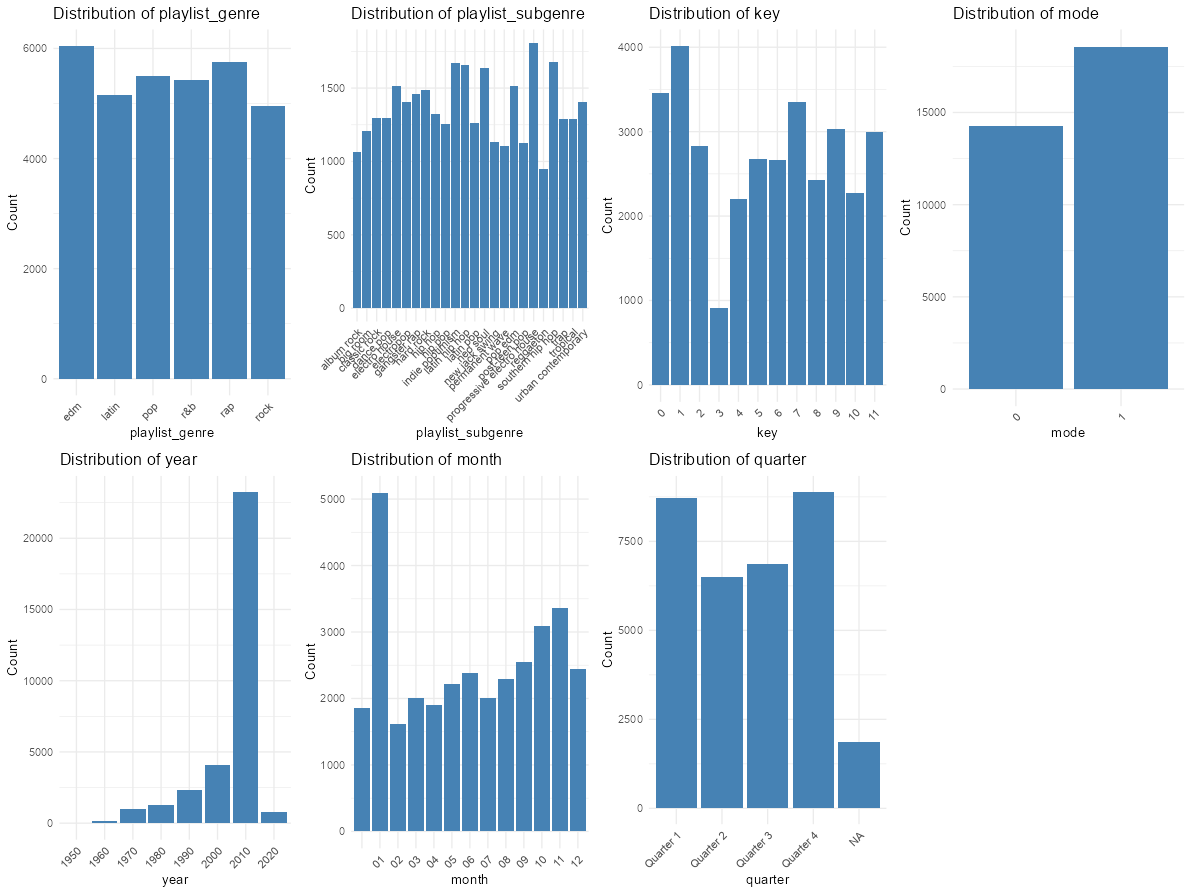

In [7]:
# Visualiser les distributions des variables catégorielles
plot_list <- list()

for (col in names(cat_df)) {
  plot_list[[col]] <- ggplot(cat_df, aes(x = .data[[col]])) +
    geom_bar(fill = "steelblue") +
    labs(x = col, y = "Count",
         title = paste("Distribution of", col)) +
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))
   
} 
options(repr.plot.width = 20, repr.plot.height = 12)
do.call(grid.arrange, c(plot_list, ncol = 4, nrow = 2))

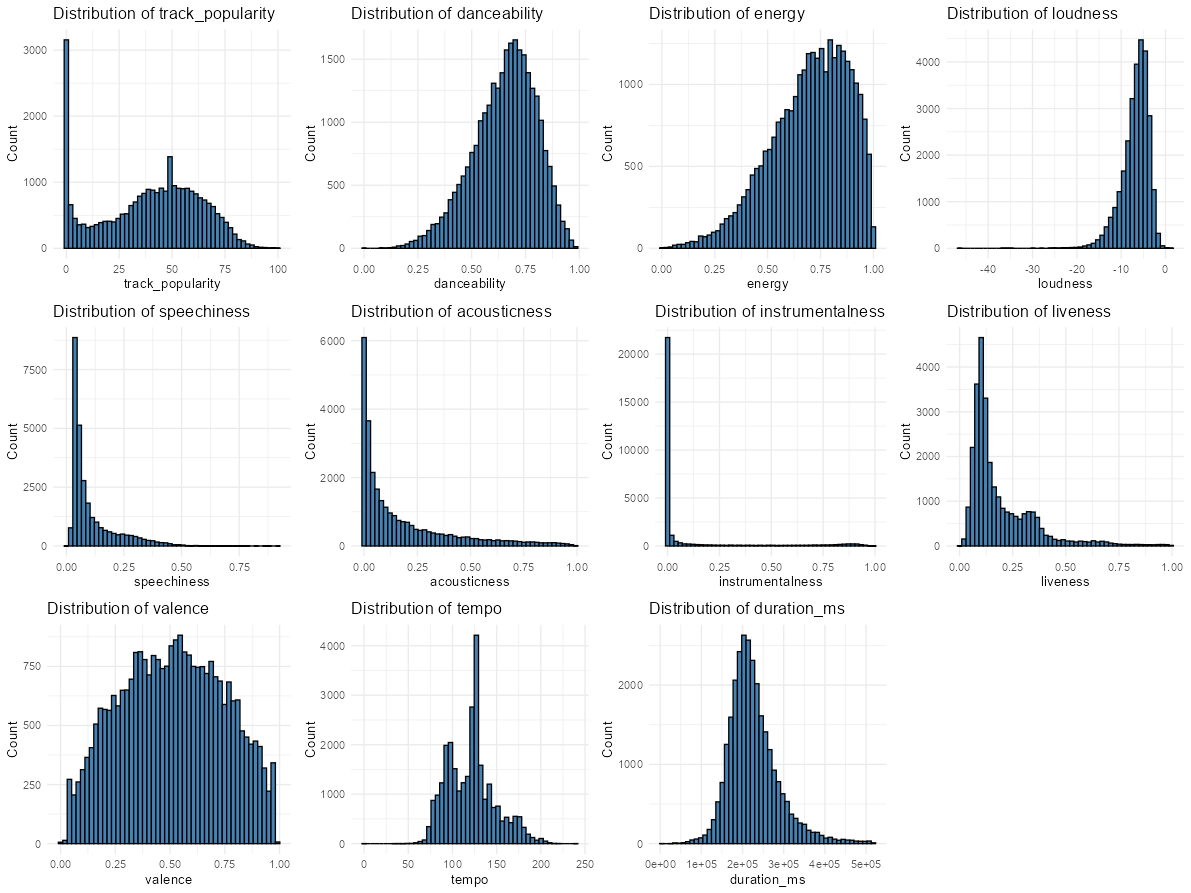

In [8]:
#Visualiser les distributions des variables numériques
plot_list <- list()
for (col in names(num_df)) {
  plot_list[[col]] <- ggplot(num_df, aes(x = .data[[col]])) +
    geom_histogram(bins = 50, fill = "steelblue", color = "black") +
    labs(x = col, y = "Count",
         title = paste("Distribution of", col)) +
    theme_minimal()
}
options(repr.plot.width = 20, repr.plot.height = 18)
do.call(grid.arrange, c(plot_list, ncol = 4, nrow = 3))

In [9]:
# Calculer le skewness pour la transformation ultérieure
library(moments)
for (col in names(num_df)) {
  skewness_value <- skewness(num_df[[col]], na.rm = TRUE)
  cat("Skewness of", col, ":", skewness_value, "\n")
}

Skewness of track_popularity : -0.2315432 
Skewness of danceability : -0.5060617 
Skewness of energy : -0.6455868 
Skewness of loudness : -1.358801 
Skewness of speechiness : 1.965565 
Skewness of acousticness : 1.575693 
Skewness of instrumentalness : 2.627647 
Skewness of liveness : 2.081978 
Skewness of valence : -0.007881982 
Skewness of tempo : 0.5138545 
Skewness of duration_ms : 1.115681 


In [10]:
# Transformation à variable factorielle
cat_df$factor_popularity <- ceiling(df$track_popularity/10)
cat_df$factor_popularity <- as.factor(cat_df$factor_popularity)
df$factor_popularity <- ceiling(df$track_popularity/10)
df$factor_popularity <- as.factor(df$factor_popularity)
cat_df$bool_instrumentalness <- ifelse(df$instrumentalness == 0, "Zero", "Non-Zero")
df$bool_instrumentalness <- ifelse(df$instrumentalness == 0, "Zero", "Non-Zero")
options(repr.plot.width = 8, repr.plot.height = 6)


In [11]:
#Transformation des variables numériques pour réduire le skewness
num_df$sqrt_speechiness <- sqrt(num_df$speechiness)
num_df$sqrt_acousticness <- sqrt(num_df$acousticness)
num_df$sqrt_duration_ms <- sqrt(num_df$duration_ms)
num_df$log_liveness <- log(num_df$liveness + 1)
num_df$cqrt_loudness <- sign(num_df$loudness) * abs(num_df$loudness)^(1/3)
df$sqrt_speechiness <- sqrt(df$speechiness)
df$sqrt_acousticness <- sqrt(df$acousticness)
df$sqrt_duration_ms <- sqrt(df$duration_ms)
df$log_liveness <- log(df$liveness + 1)
df$cqrt_loudness <- sign(df$loudness) * abs(df$loudness)^(1/3)
df <- df %>% dplyr::select(-c(speechiness, acousticness, duration_ms, liveness, loudness))
num_df %>% dplyr :: select(-c(speechiness, acousticness, duration_ms, liveness, instrumentalness,loudness)) -> num_df

In [47]:
#Faire une ANOVA pour chaque variable numérique en fonction de chaque variable catégorielle
num_vars <- names(num_df)
cat_vars <- names(cat_df)
pval_matrix <- matrix(NA, nrow = length(num_vars), ncol = length(cat_vars),
                      dimnames = list(num_vars, cat_vars))
for (cat_col in cat_vars) {
    for (num_col in num_vars){
        formula <- as.formula(paste(num_col, "~", cat_col))
        model <- lm(formula, data = df)
        df.aov <- anova(model)
        pval_matrix[num_col, cat_col] <- df.aov$`Pr(>F)`[1]
    }
}
pval_df <- as.data.frame(pval_matrix)
print(pval_df)

                  playlist_genre playlist_subgenre          key         mode
track_popularity   2.702657e-218      0.000000e+00 1.988223e-05 5.394028e-02
danceability        0.000000e+00      0.000000e+00 8.403977e-74 2.035418e-26
energy              0.000000e+00      0.000000e+00 4.047891e-12 3.844765e-01
valence             0.000000e+00      0.000000e+00 2.944886e-16 6.356985e-01
tempo              3.272718e-147     9.858056e-220 1.290336e-05 9.419525e-03
sqrt_speechiness    0.000000e+00      0.000000e+00 4.888261e-80 7.165962e-40
sqrt_acousticness   0.000000e+00      0.000000e+00 2.897930e-30 8.151056e-01
sqrt_duration_ms   1.949270e-311      0.000000e+00 1.182305e-16 5.086051e-03
log_liveness        5.991555e-56      2.282519e-97 1.334488e-15 2.790239e-01
cqrt_loudness       0.000000e+00      0.000000e+00 1.320625e-19 9.095210e-04
                           year         month      quarter factor_popularity
track_popularity  1.711428e-141  7.462157e-64 2.364186e-47      0.000000e+00

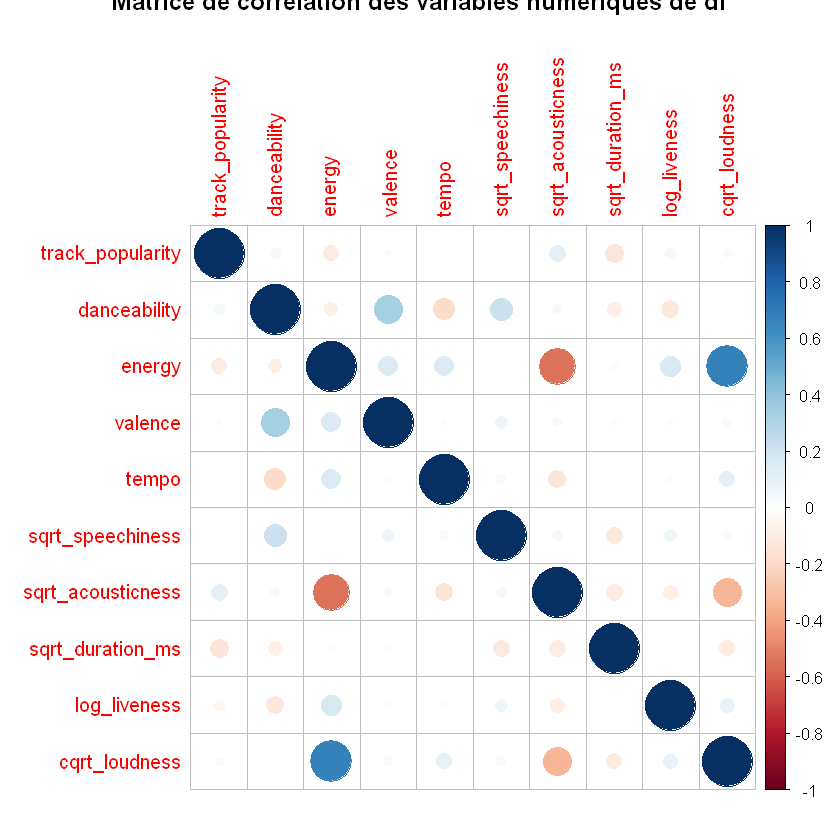

In [ ]:
corrplot(cor(num_df), title = "Matrice de corrélation des variables numériques de df")

In [ ]:
#Khi-deux test pour chaque paire de variables catégorielles
results <- data.frame()

for (i in 1:(ncol(cat_df) - 1)) {
  for (j in (i + 1):ncol(cat_df)) {
    test <- chisq.test(table(cat_df[[i]], cat_df[[j]]))
    
    results <- rbind(results, data.frame(
      var1    = names(cat_df)[i],
      var2    = names(cat_df)[j],
      chi_sq  = round(test$statistic, 3),
      p_value = test$p.value
    ))
  }
}
print(results)

Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(table(cat_df[[i]], cat_df[[j]])):
"Chi-squared approximation may be incorrect"


                         var1                  var2     chi_sq       p_value
X-squared      playlist_genre     playlist_subgenre 164165.000  0.000000e+00
X-squared1     playlist_genre                   key    943.906 3.957663e-162
X-squared2     playlist_genre                  mode    516.795 1.891477e-109
X-squared3     playlist_genre                  year  12000.737  0.000000e+00
X-squared4     playlist_genre                 month   1836.393  0.000000e+00
X-squared5     playlist_genre               quarter    231.407  8.223388e-41
X-squared6     playlist_genre bool_instrumentalness   2496.988  0.000000e+00
X-squared7  playlist_subgenre                   key   1445.238 5.269916e-166
X-squared8  playlist_subgenre                  mode    758.696 1.852956e-145
X-squared9  playlist_subgenre                  year  20934.367  0.000000e+00
X-squared10 playlist_subgenre                 month   3795.826  0.000000e+00
X-squared11 playlist_subgenre               quarter   1040.380 2.522739e-173

# II. Réduction dimensionelle

## 1. ACP

In [ ]:
#ACP
df.acp <- PCA(num_df,scale.unit = TRUE)

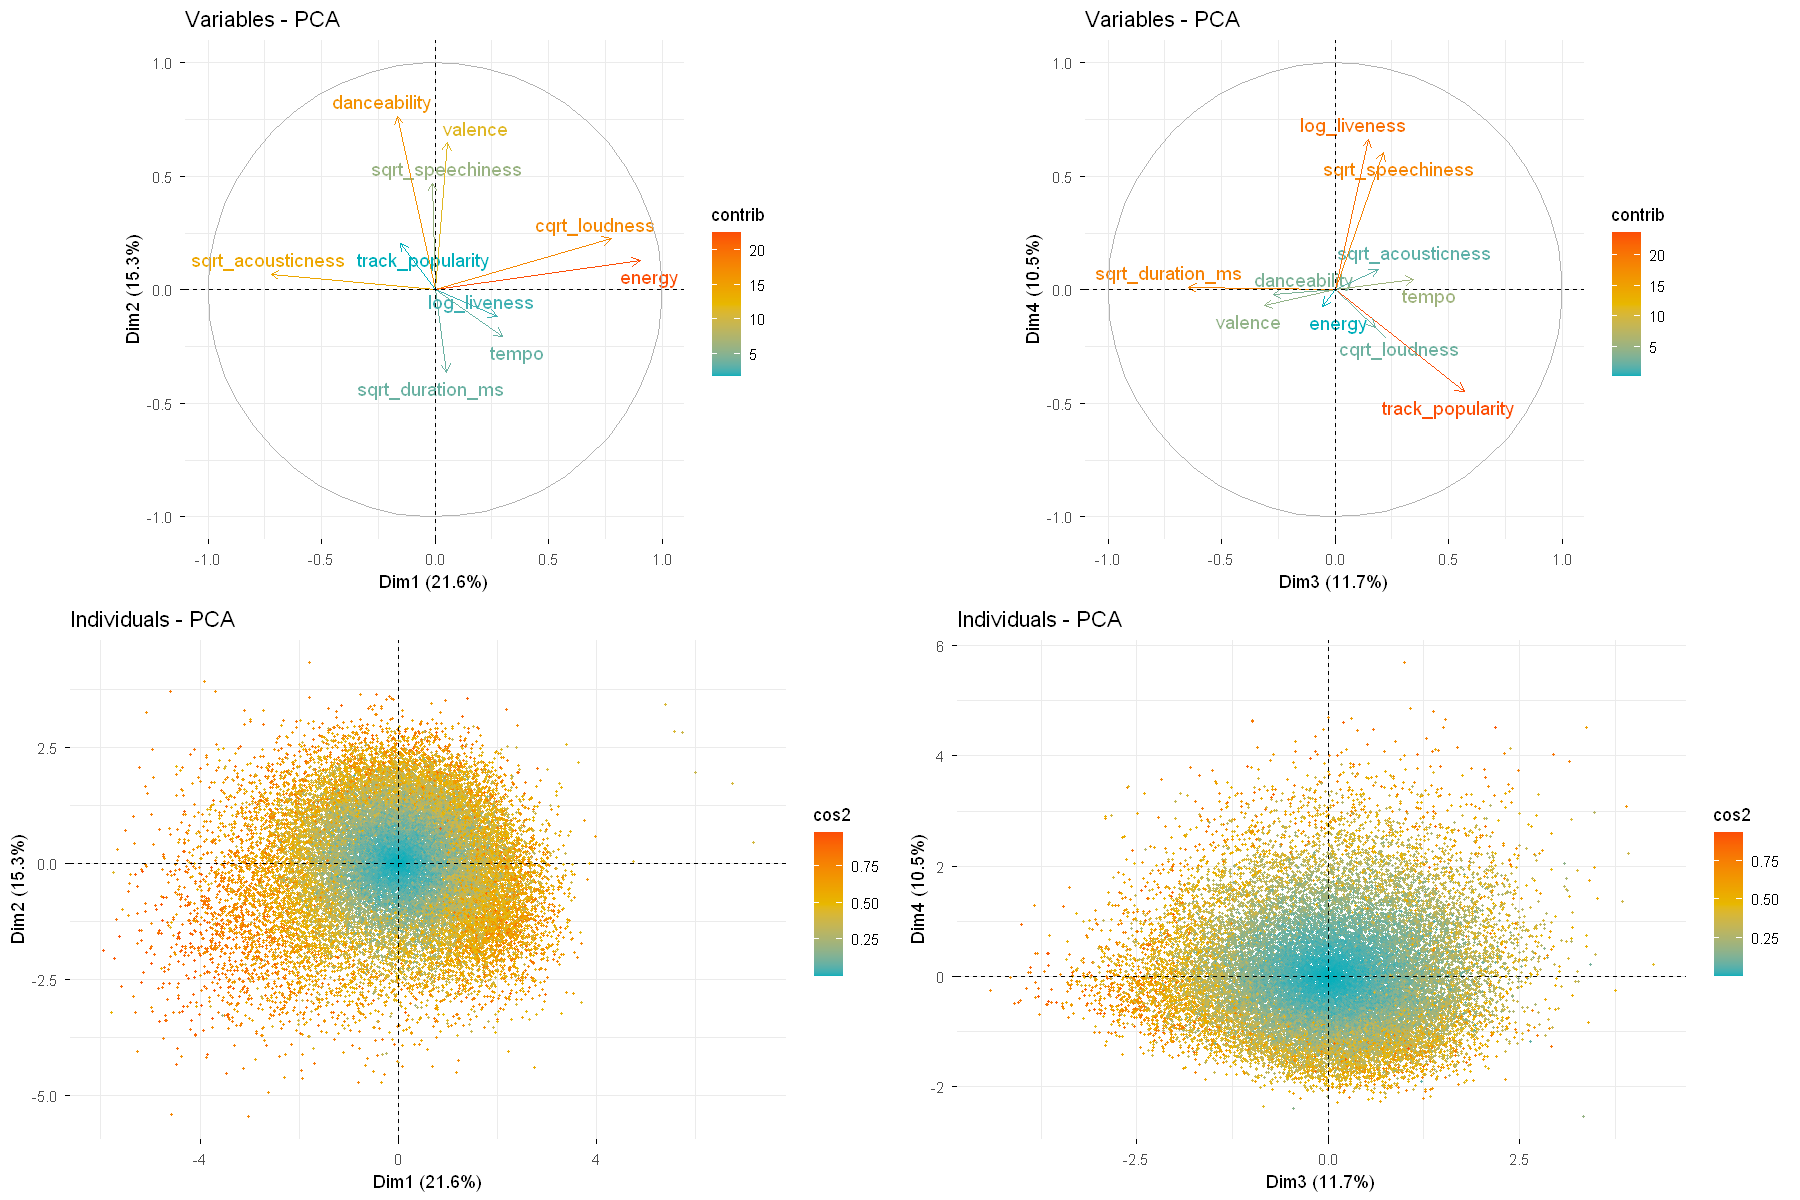

In [ ]:
#Visualiser les résultats de l'ACP
p1 <- fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),repel = TRUE)
p2 <- fviz_pca_var(df.acp, col.var = "contrib",gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),axes= c(3,4),repel = TRUE)
p3 <- fviz_pca_ind(df.acp,col.ind = "cos2",label='none',gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),pointsize = 0.5)
p4 <- fviz_pca_ind(df.acp,col.ind = "cos2",label='none',gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),pointsize = 0.5,axes = c(3,4))
options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, p3, p4, ncol = 2)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


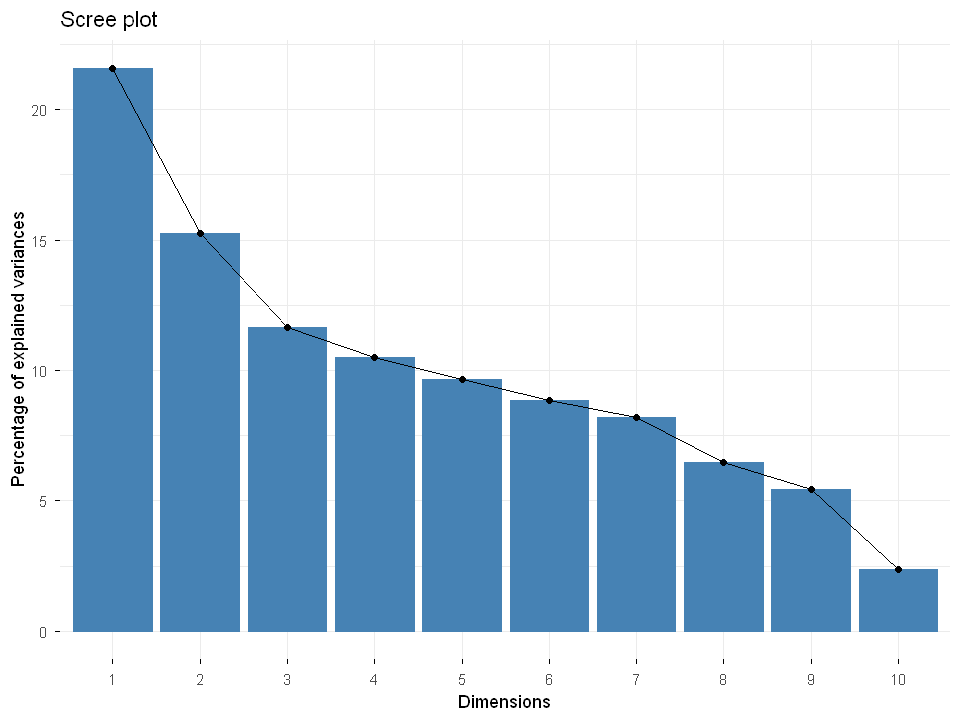

In [ ]:
# Variance expliquée par les composantes principales
options(repr.plot.width = 8, repr.plot.height = 6)
fviz_eig(df.acp)

## 2. LDA

In [63]:
#LDA
genre_num_df <- df %>% dplyr :: select(playlist_genre, where(is.numeric)) %>% na.omit()
genre_num_df$playlist_genre <- as.factor(genre_num_df$playlist_genre)
df.lda <- lda(playlist_genre ~ ., data = genre_num_df)
df.lda.pred <- predict(df.lda)
df.lda.acp <- PCA(genre_num_df,scale.unit = TRUE,quali.sup = 1)


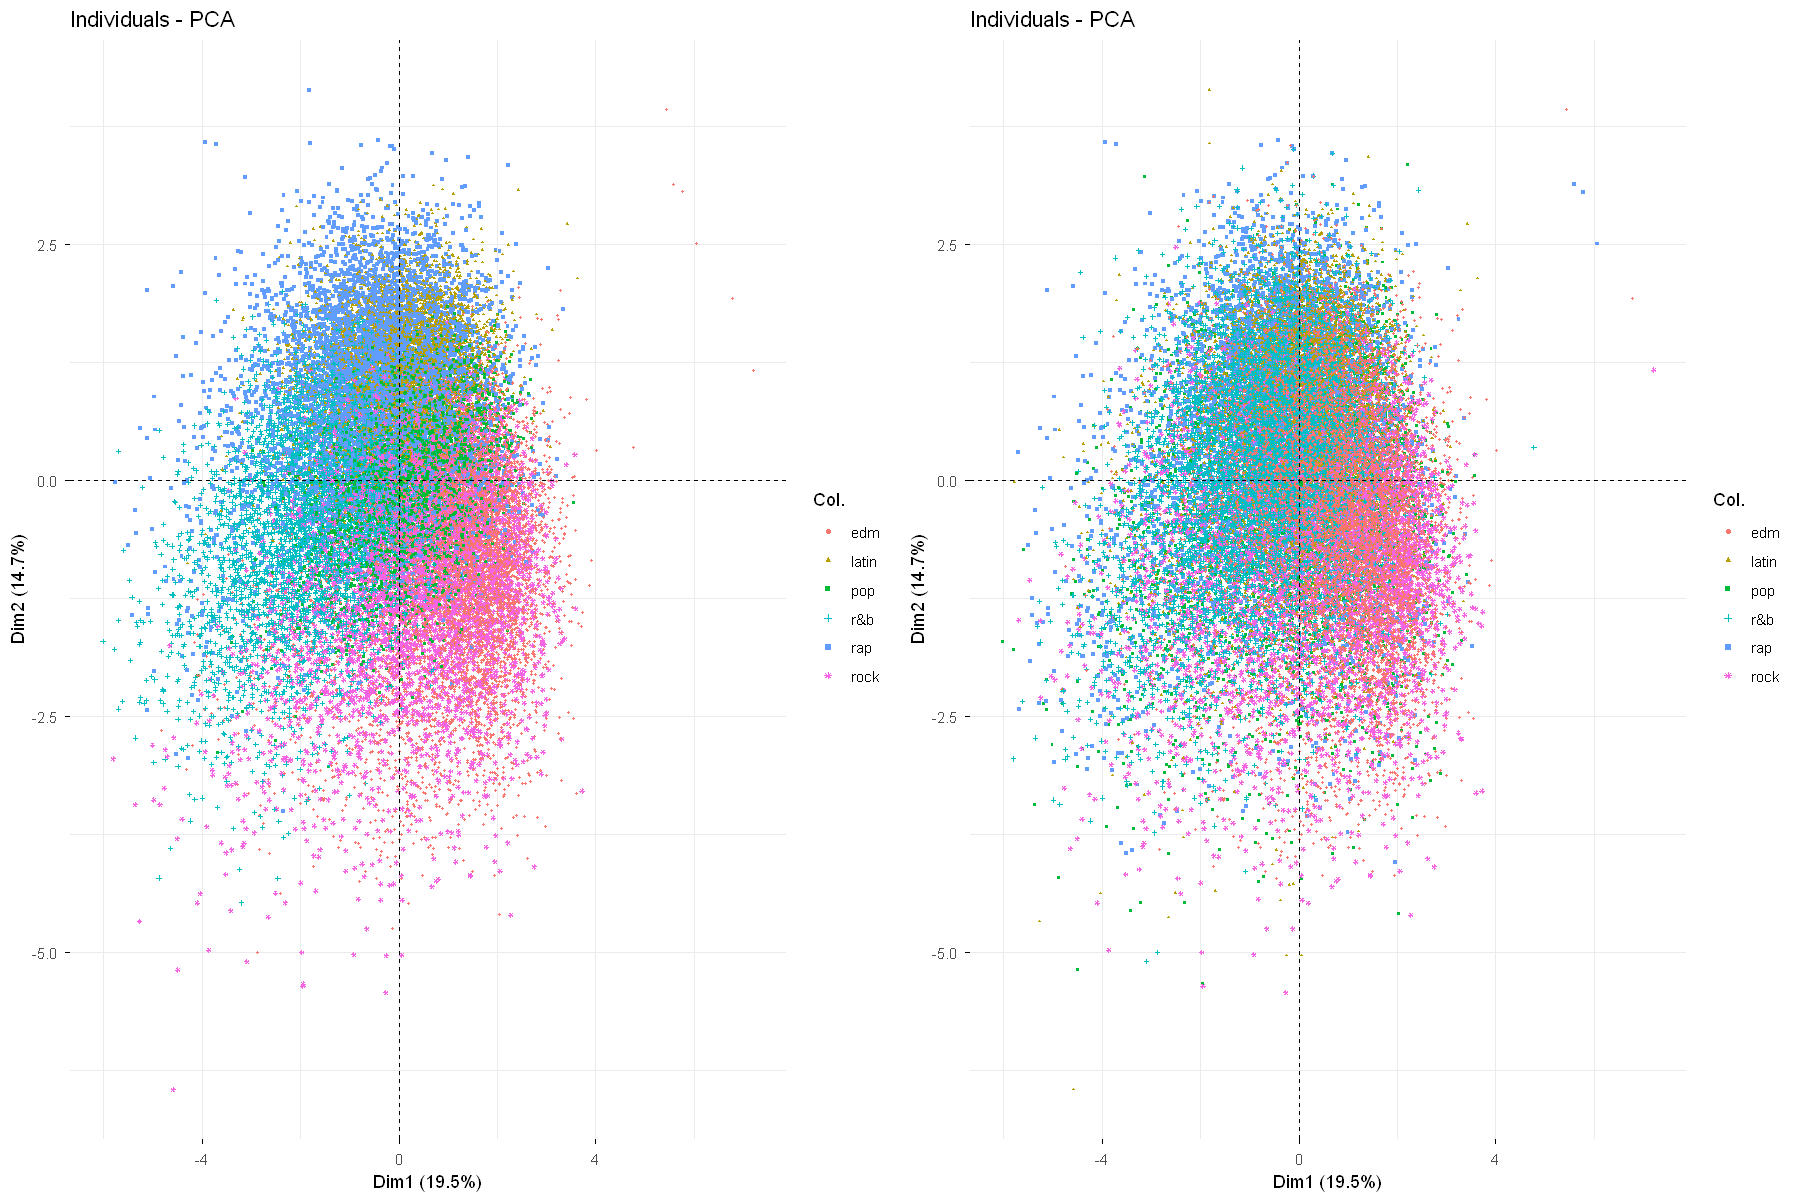

In [ ]:
#Comparer les classes prédites par LDA avec les genres réelles
p1 <- fviz_pca_ind(df.lda.acp, col.ind = df.lda.pred$class,label='none',pointsize = 0.5)
p2 <- fviz_pca_ind(df.lda.acp, col.ind = df$playlist_genre,label='none',pointsize = 0.5)
options(repr.plot.width = 15, repr.plot.height = 10)
grid.arrange(p1, p2, ncol = 2)

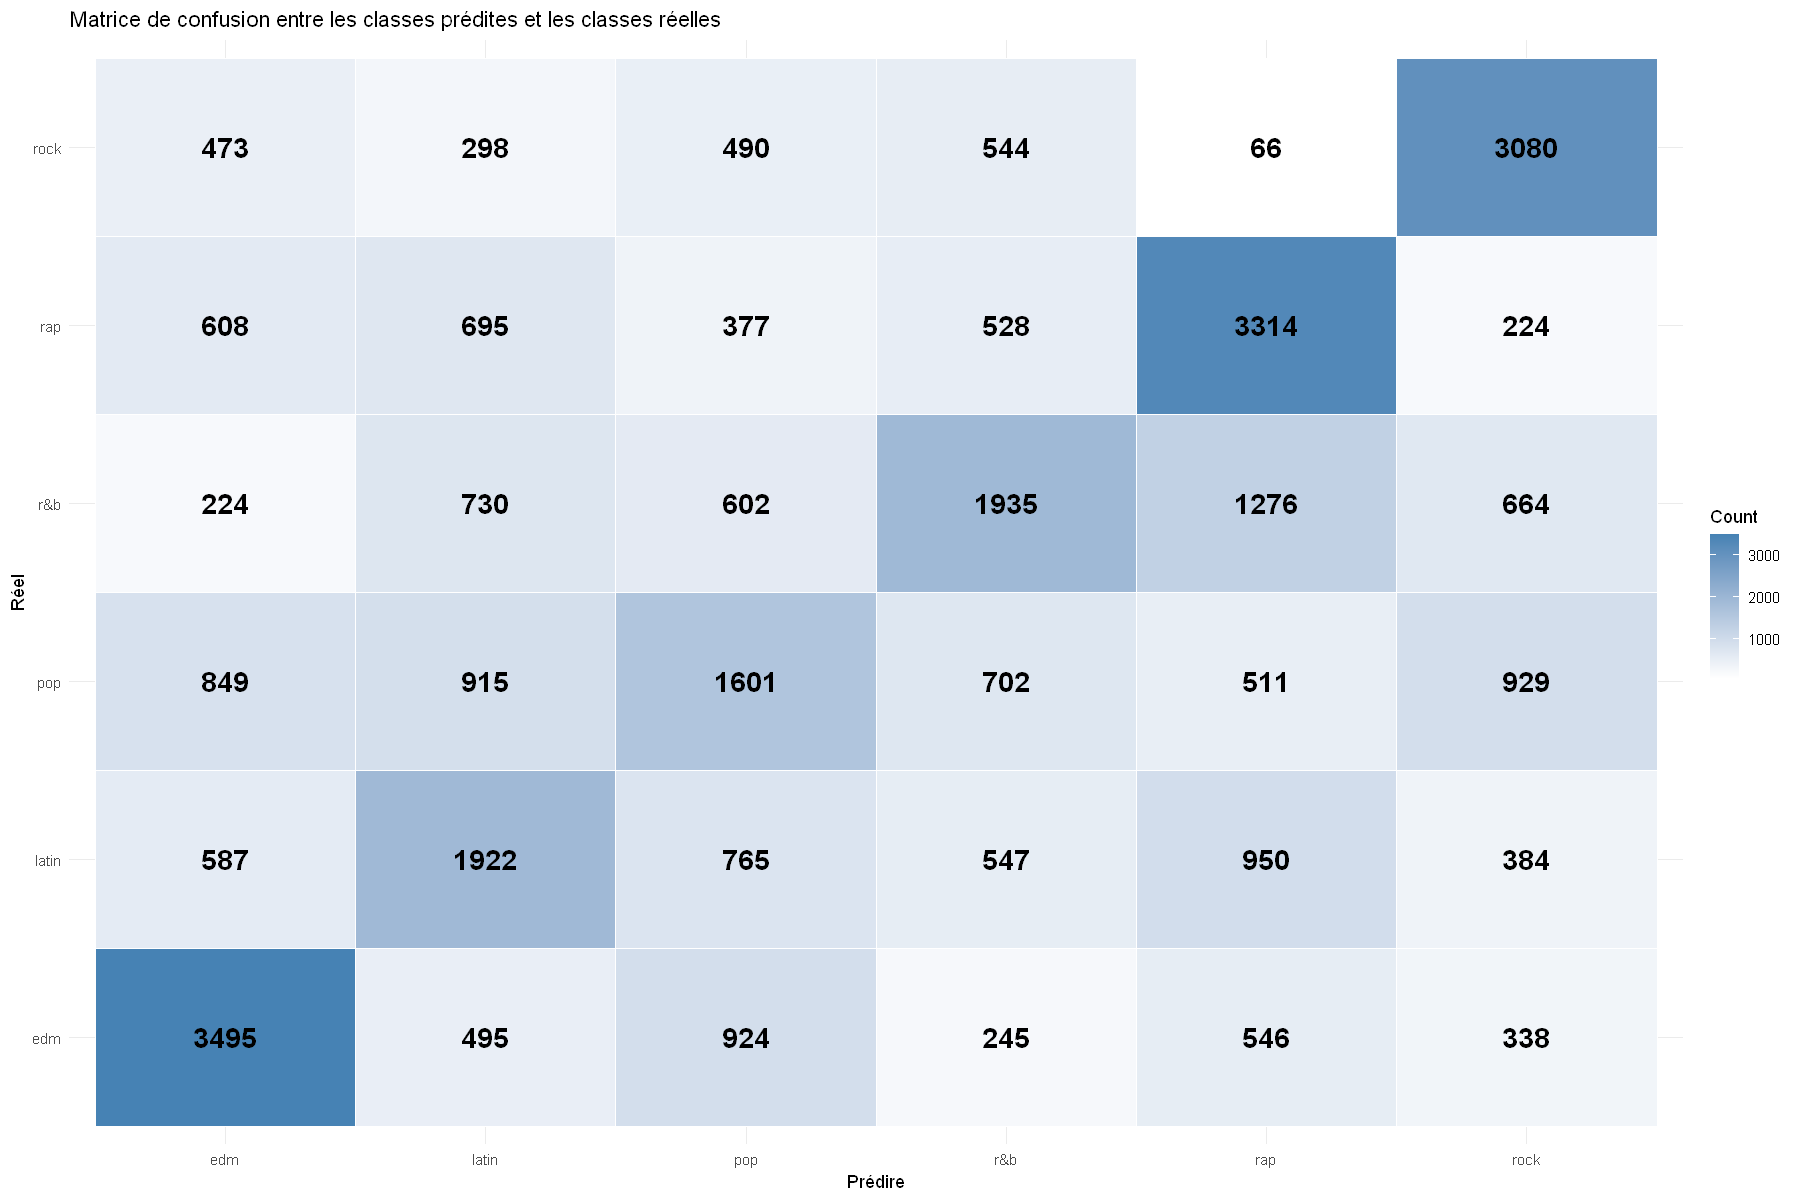

In [ ]:
# Confusion matrix
cm <- as.data.frame(table(Prédire = df.lda.pred$class, Réel = genre_num_df$playlist_genre))
ggplot(cm, aes(x = Prédire, y = Réel, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), size = 6, fontface = "bold") +
  scale_fill_gradient(low = "white", high = "steelblue") +
  theme_minimal() +
  labs(title = "Matrice de confusion entre les classes prédites et les classes réelles", fill = "Count")

## 3. CA

In [ ]:
# CA entre les paires de variables catégorielles utiles pour l'analyse de la popularité
table.key_genre <- table(cat_df$key, cat_df$playlist_genre)
df.ca.key_genre <- CA(table.key_genre, graph = FALSE)
p1 <- fviz_ca_biplot(df.ca.key_genre, repel = TRUE)
p2 <- fviz_screeplot(df.ca.key_genre, addlabels = TRUE, ylim = c(0, 100))
table.key_subgenre <- table(cat_df$key, cat_df$playlist_subgenre)
df.ca.key_subgenre <- CA(table.key_subgenre, graph = FALSE)
p3 <- fviz_ca_biplot(df.ca.key_subgenre, repel = TRUE)
p4 <- fviz_screeplot(df.ca.key_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.year_genre <- table(cat_df$year, cat_df$playlist_genre)
df.ca.year_genre <- CA(table.year_genre, graph = FALSE)
p5 <- fviz_ca_biplot(df.ca.year_genre, repel = TRUE)
p6 <- fviz_screeplot(df.ca.year_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.year_subgenre <- table(cat_df$year, cat_df$playlist_subgenre)
df.ca.year_subgenre <- CA(table.year_subgenre, graph = FALSE)
p7 <- fviz_ca_biplot(df.ca.year_subgenre, repel = TRUE)
p8 <- fviz_screeplot(df.ca.year_subgenre, addlabels = TRUE)
table.quarter_genre <- table(cat_df$quarter, cat_df$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = FALSE)
p9 <- fviz_ca_biplot(df.ca.quarter_genre, repel = TRUE)
p10 <-fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.quarter_subgenre <- table(cat_df$quarter, cat_df$playlist_subgenre)
df.ca.quarter_subgenre <- CA(table.quarter_subgenre, graph = FALSE)
p11 <- fviz_ca_biplot(df.ca.quarter_subgenre, repel = TRUE)
p12 <- fviz_screeplot(df.ca.quarter_subgenre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.quarter_popularity <- table(cat_df$quarter, cat_df$factor_popularity)
df.ca.quarter_popularity <- CA(table.quarter_popularity, graph = FALSE)
p13 <- fviz_ca_biplot(df.ca.quarter_popularity, repel = TRUE)
p14 <- fviz_screeplot(df.ca.quarter_popularity, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)
table.genre_popularity <- table(cat_df$playlist_genre, cat_df$factor_popularity)
df.ca.genre_popularity <- CA(table.genre_popularity, graph = FALSE)
p15 <- fviz_ca_biplot(df.ca.genre_popularity, repel = TRUE)
p16 <- fviz_screeplot(df.ca.genre_popularity, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)



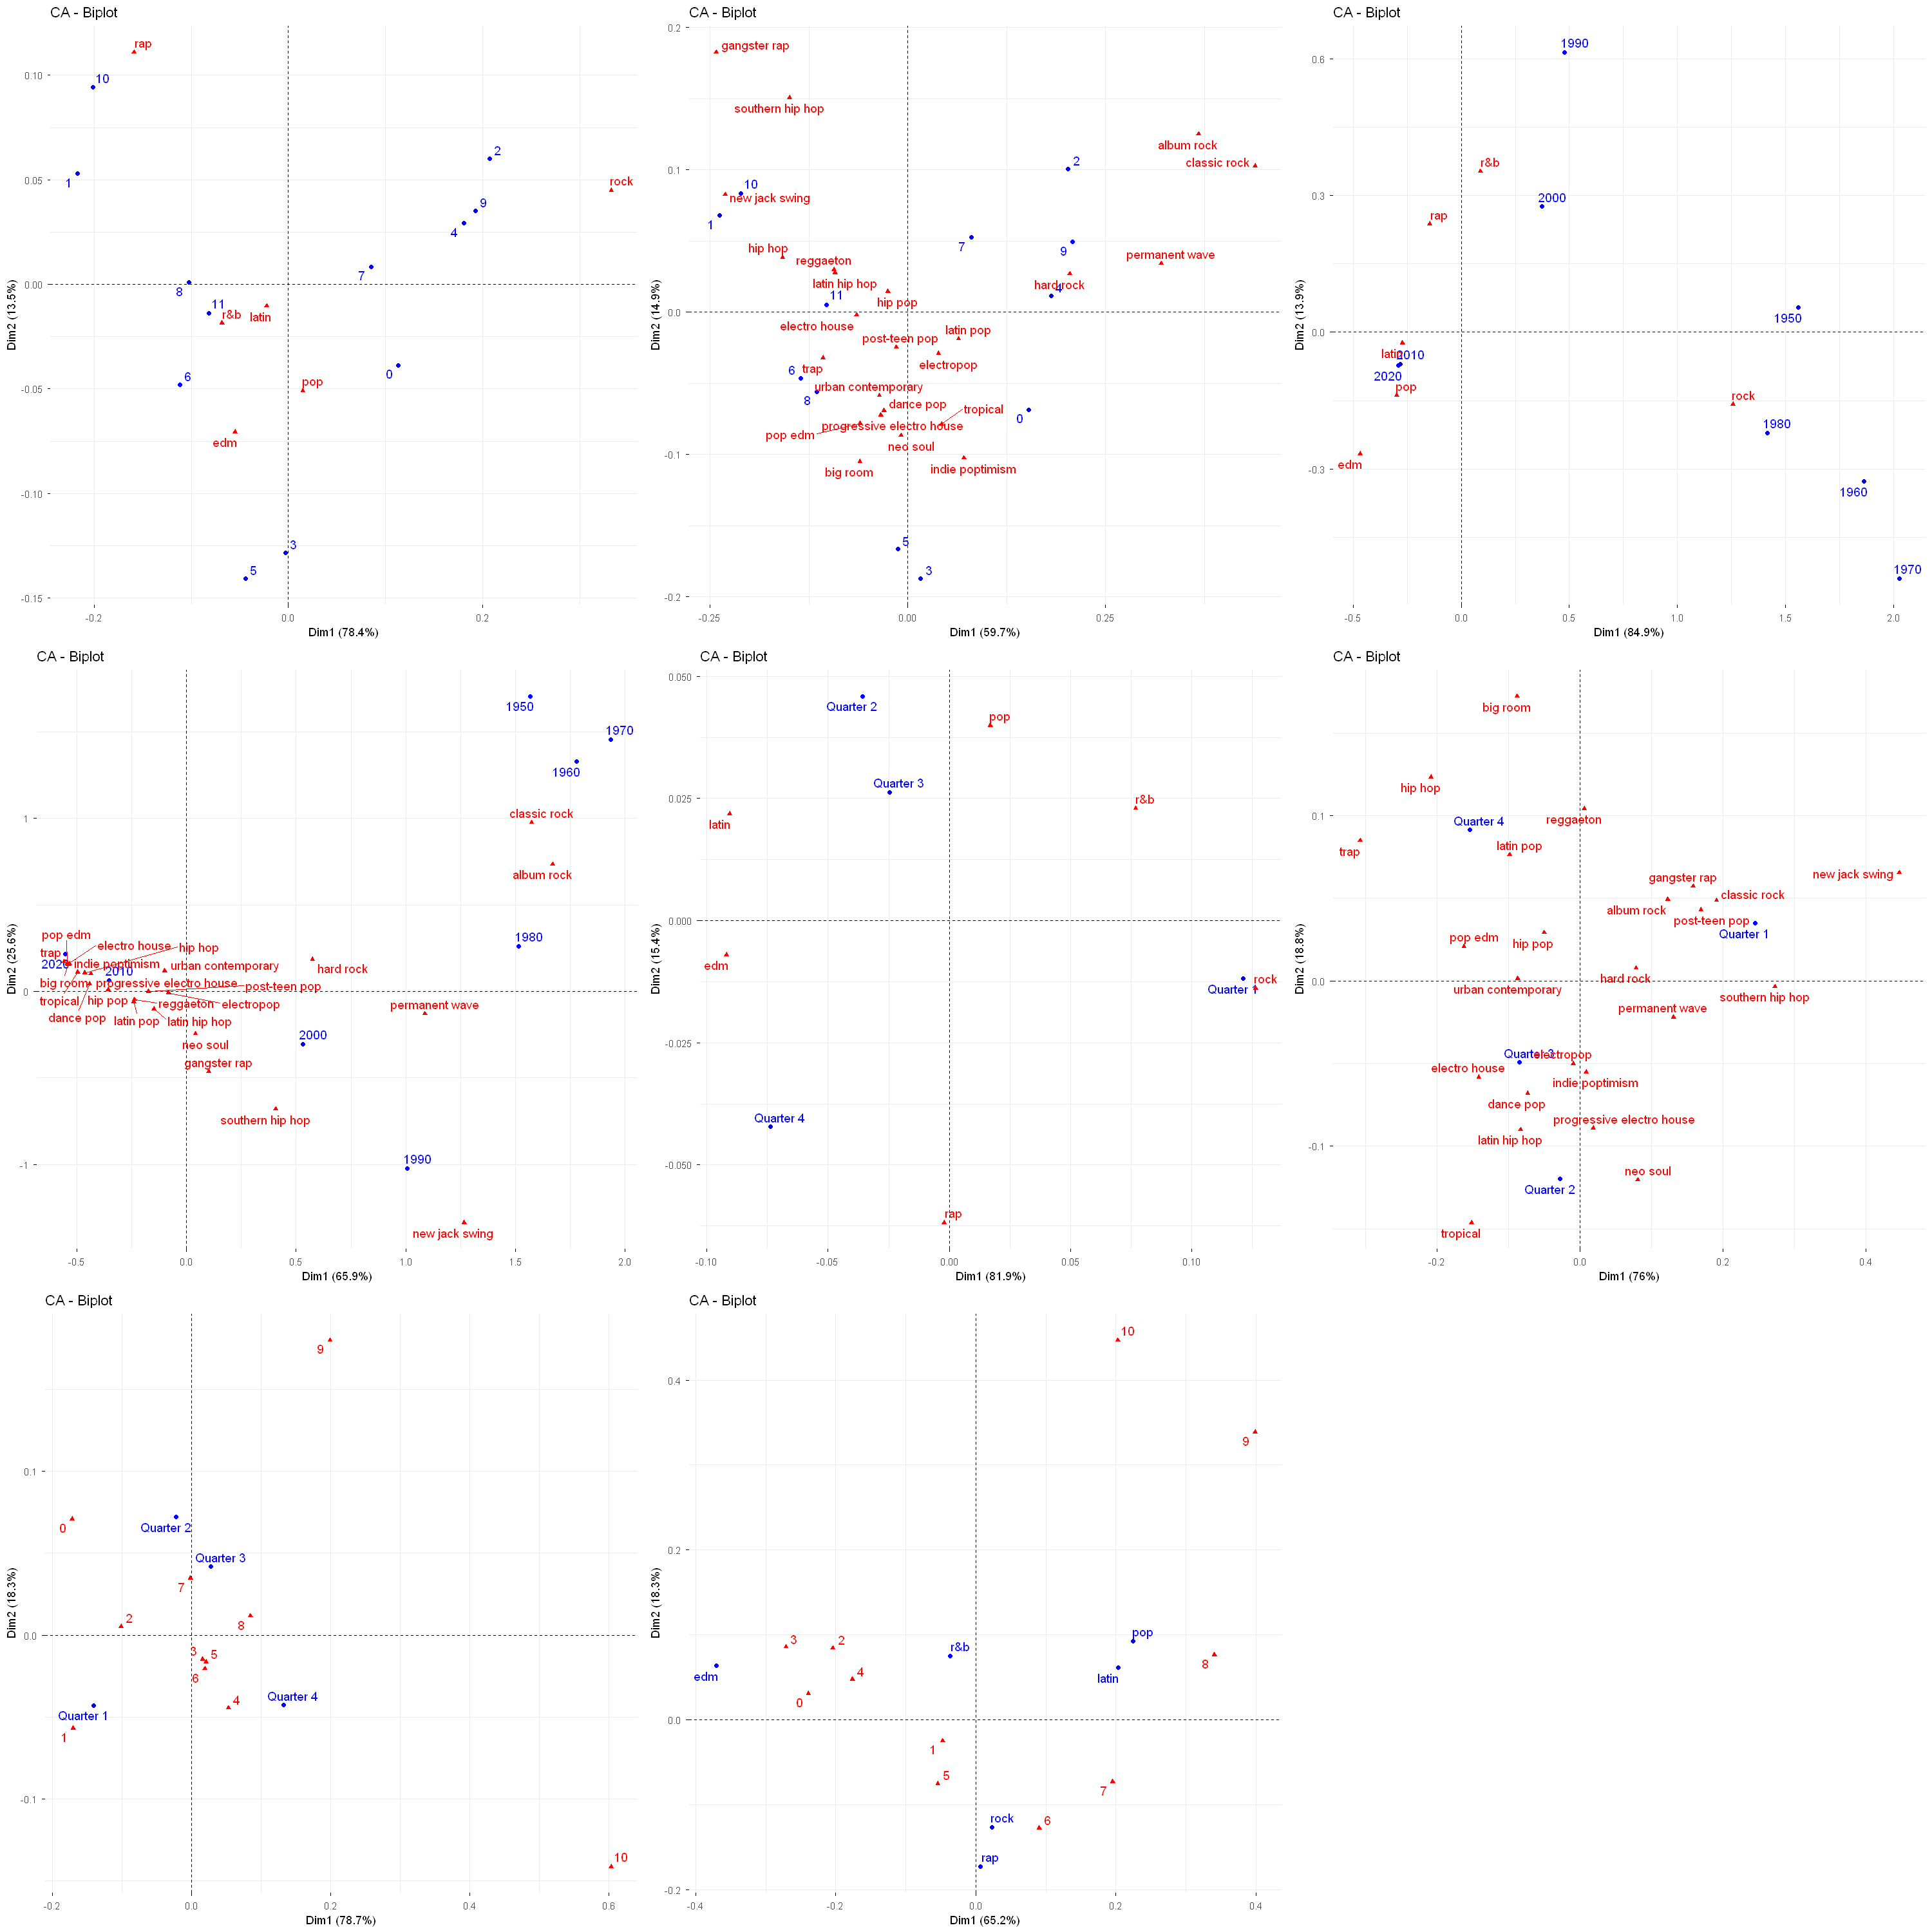

In [ ]:
# Visualiser la corrélation entre les variables catégorielles 
options(repr.plot.width = 25, repr.plot.height = 25)
grid.arrange(p1, p3, p5, p7, p9, p11, p13, p15, ncol = 3)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


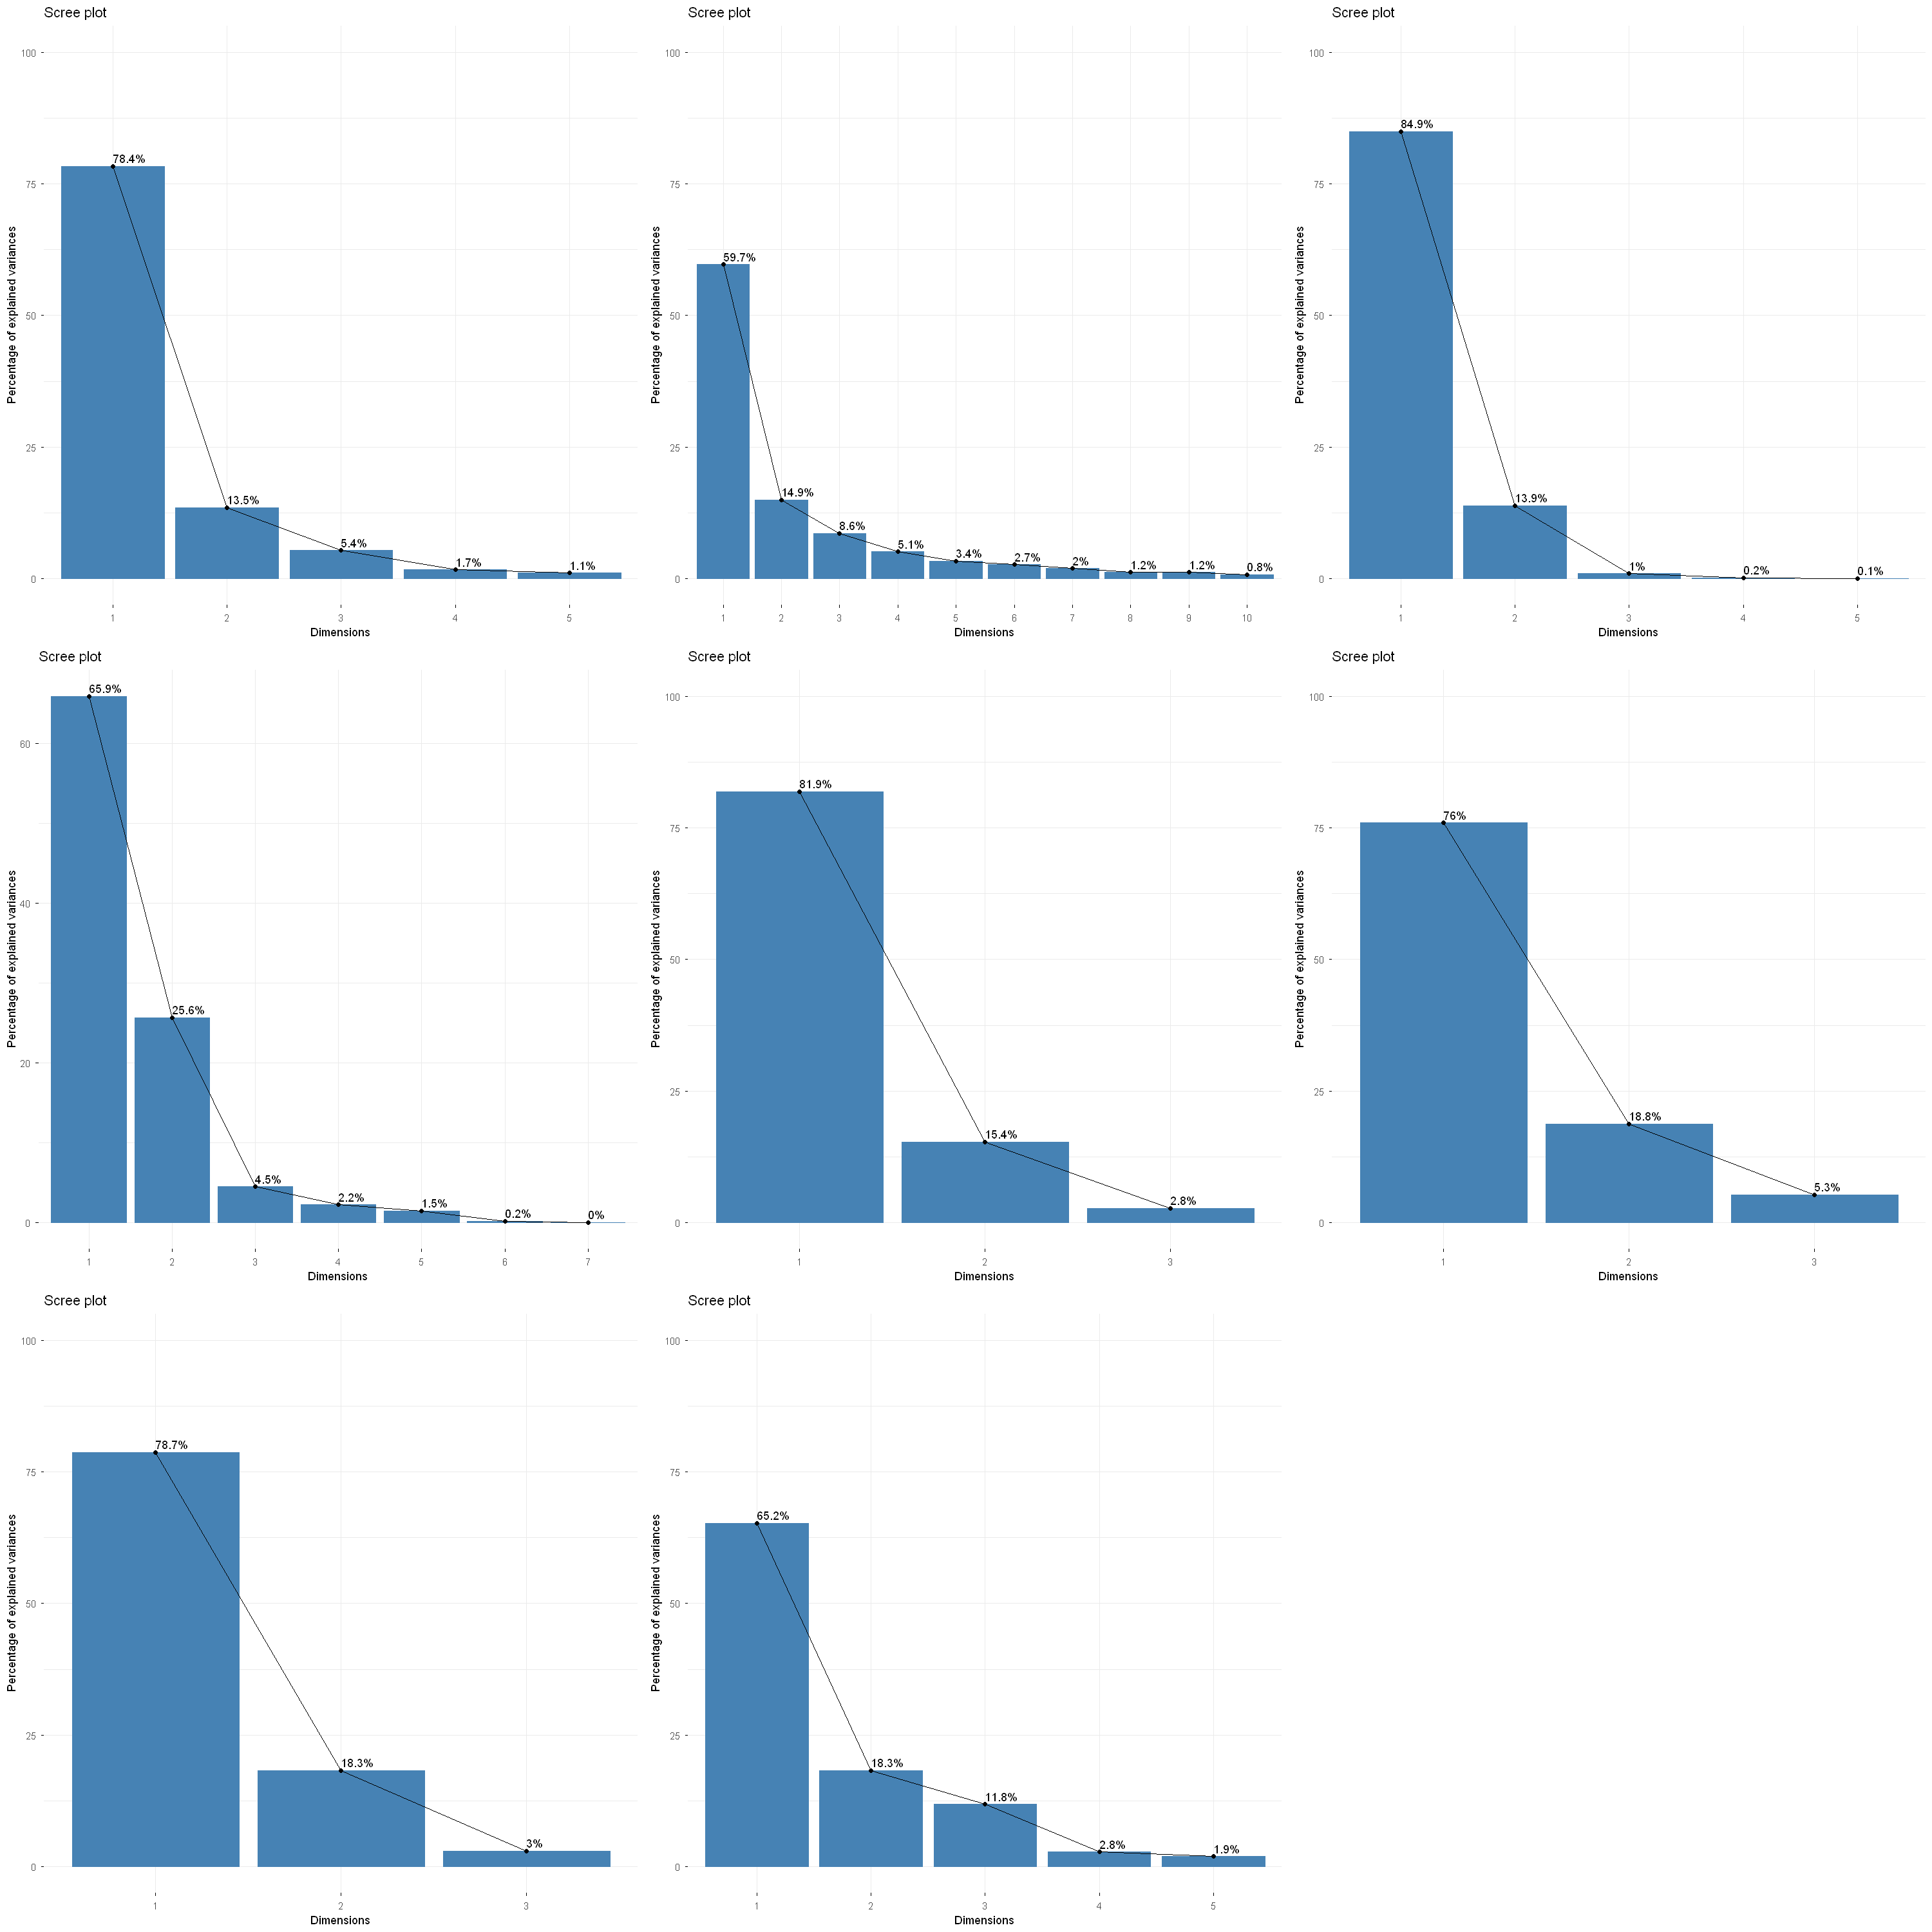

In [ ]:
# Visualiser les screeplots pour chaque CA
grid.arrange(p2, p4, p6, p8, p10, p12, p14, p16, ncol = 3)

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


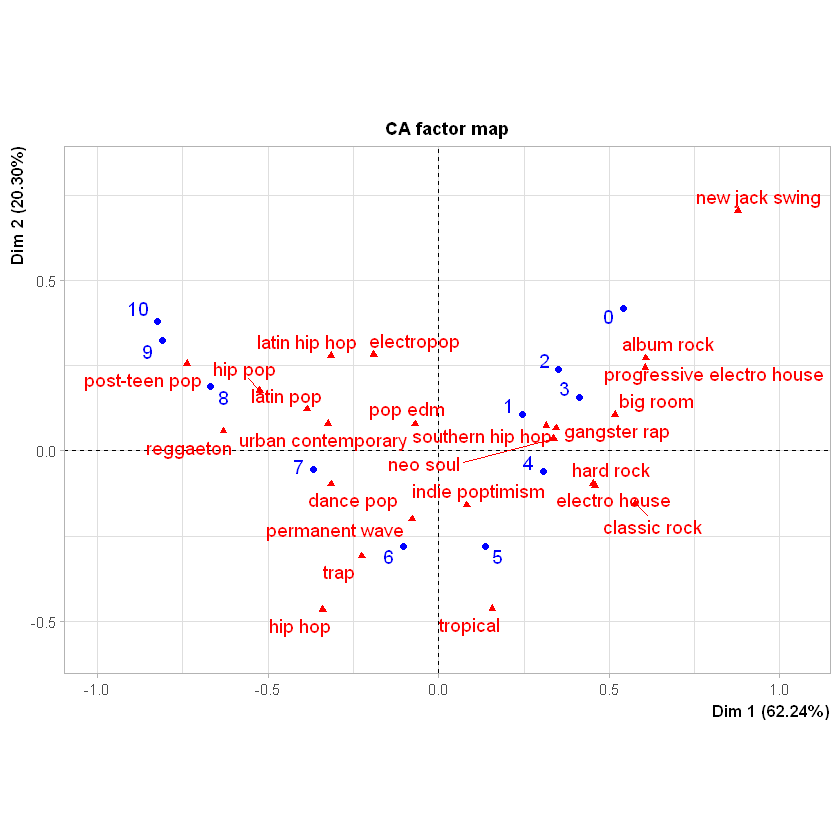

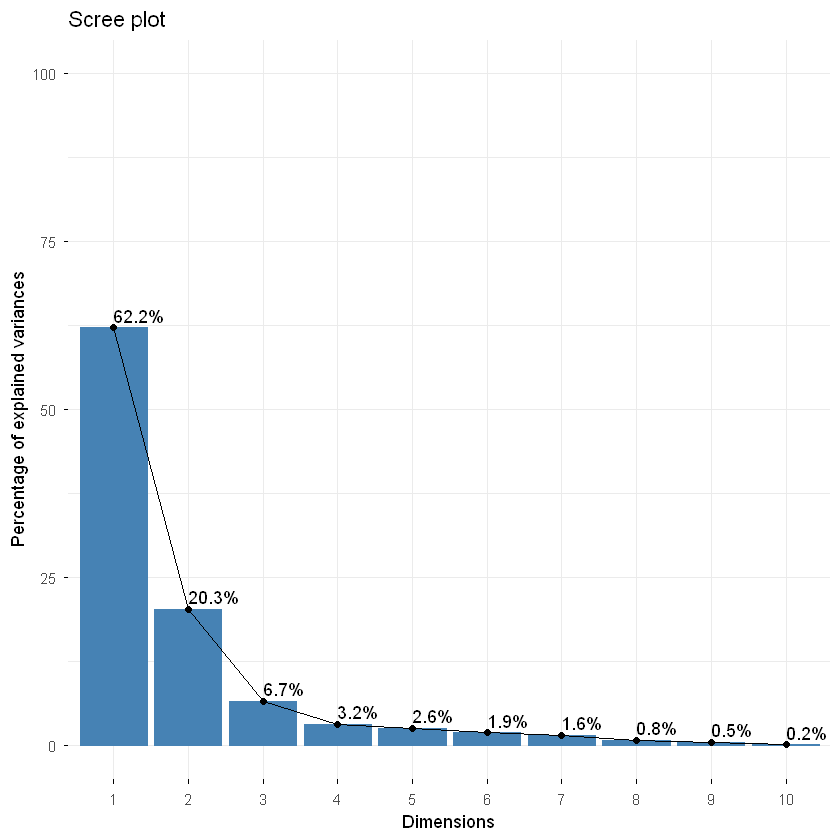

In [ ]:

table.quarter_genre <- table(cat_df[cat_df$year == 2020 | cat_df$year == 2010,]$factor_popularity, cat_df[cat_df$year == 2020 | cat_df$year == 2010,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The rows 10 sum at 0. They were suppressed from the analysis"
Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The columns pop edm, trap sum at 0. They were suppressed from the analysis"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


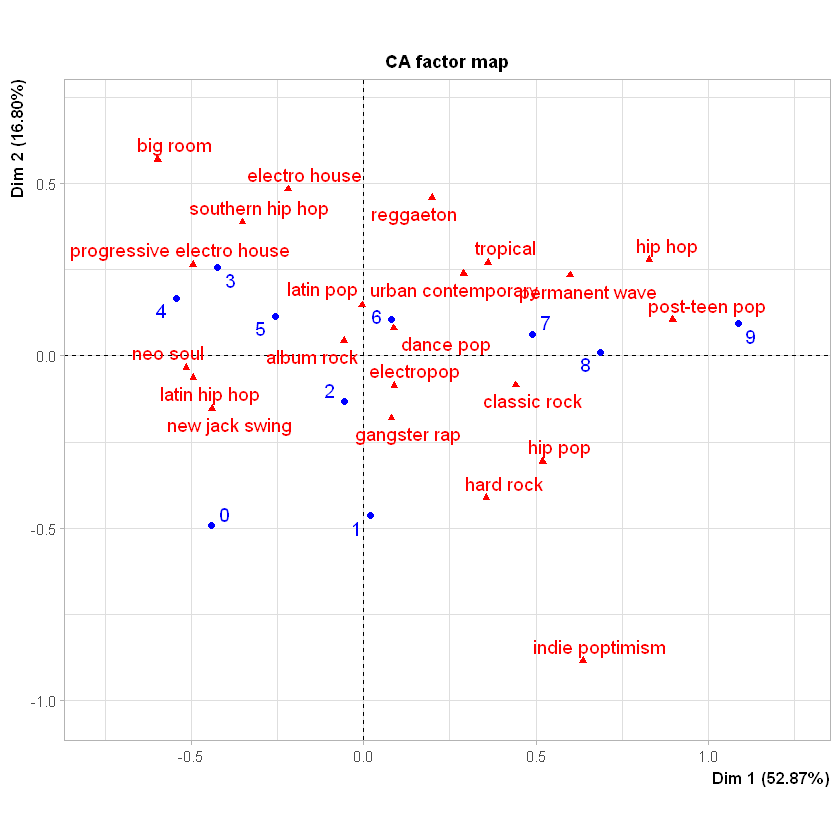

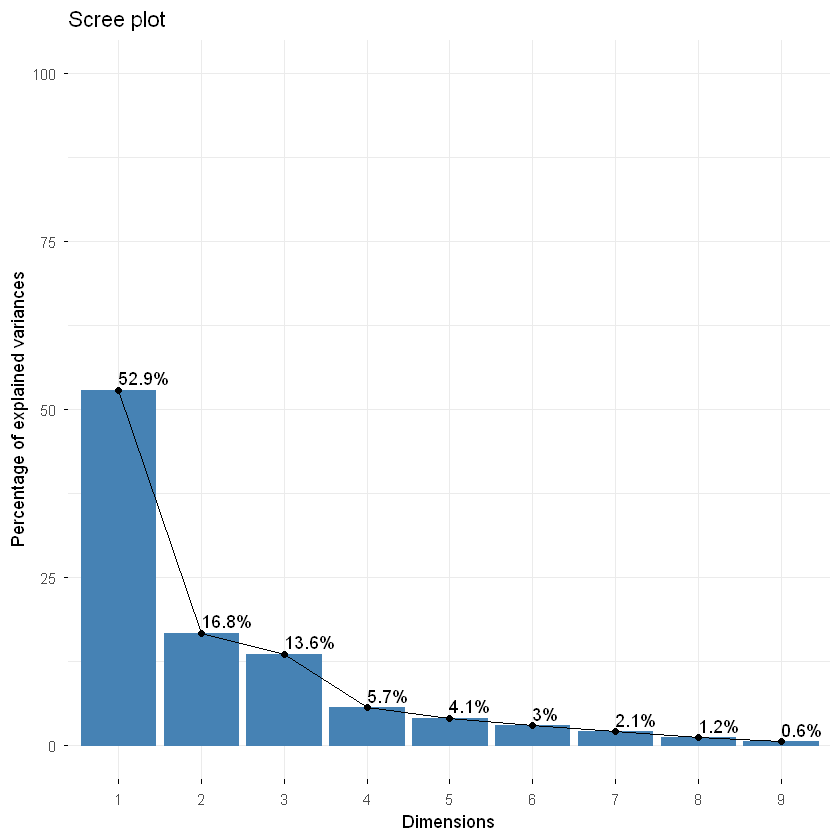

In [ ]:
table.quarter_genre <- table(cat_df[cat_df$year == 1990 | cat_df$year == 2000,]$factor_popularity, cat_df[cat_df$year == 1990 | cat_df$year == 2000,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The rows 10 sum at 0. They were suppressed from the analysis"
Warning message in CA(table.quarter_subgenre, graph = TRUE):
"The columns big room, dance pop, electro house, gangster rap, hip hop, hip pop, indie poptimism, pop edm, reggaeton, trap, tropical sum at 0. They were suppressed from the analysis"
Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


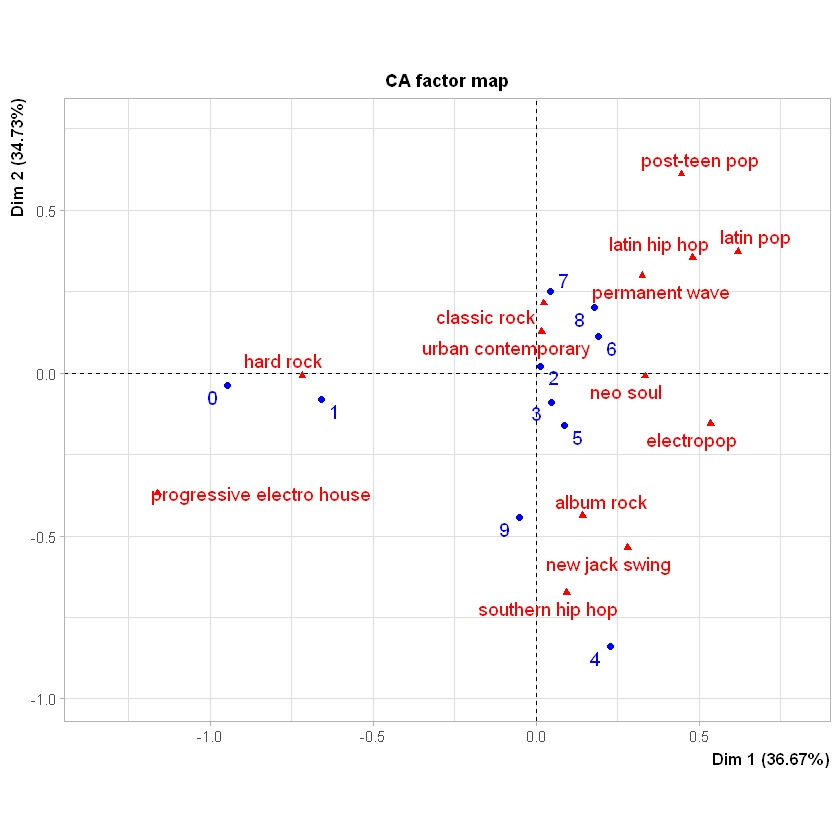

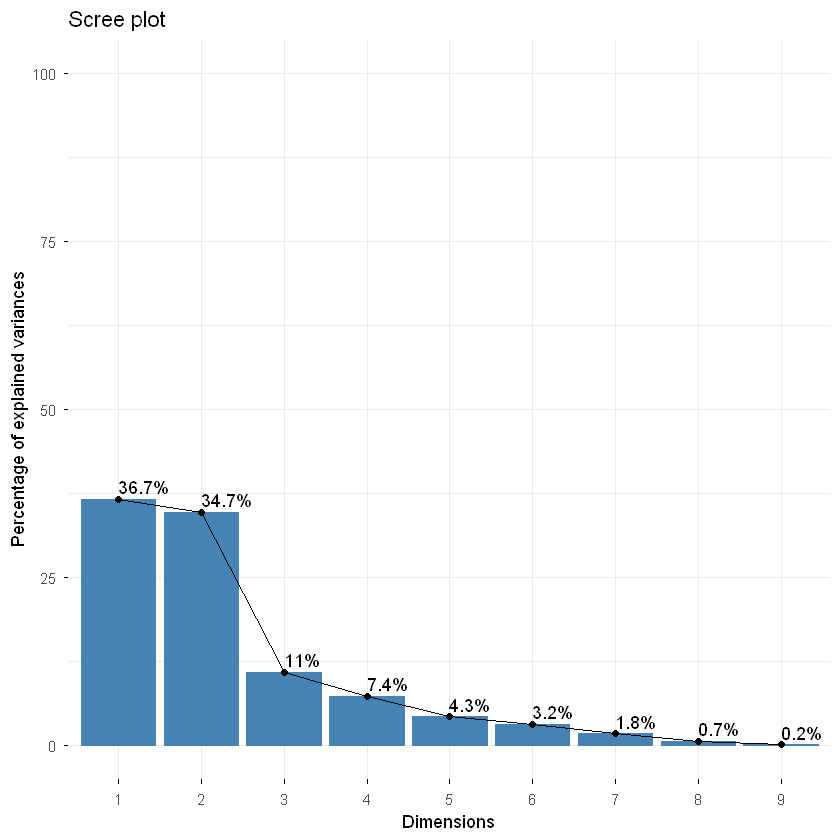

In [ ]:
table.quarter_genre <- table(cat_df[cat_df$year == 1980 | cat_df$year == 1970,]$factor_popularity, cat_df[cat_df$year == 1980 | cat_df$year == 1970,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

In [ ]:
table.quarter_genre <- table(cat_df[cat_df$year == 1960 | cat_df$year == 1950,]$factor_popularity, cat_df[cat_df$year == 1950 | cat_df$year == 1960,]$playlist_genre)
df.ca.quarter_genre <- CA(table.quarter_genre, graph = TRUE)
fviz_screeplot(df.ca.quarter_genre, addlabels = TRUE, ylim = c(0, 100),repel = TRUE)

In [ ]:
# Table de contingence
options(repr.plot.width = 8, repr.plot.height = 6)

tab_genre_pop <- table(df$playlist_genre, df$factor_popularity)

# AFC
afc1 <- CA(tab_genre_pop, graph = FALSE)

# Visualisation
fviz_ca_biplot(afc1, repel = TRUE, ggtheme = theme_minimal()) +
  labs(title = "AFC — Genre × Popularité")

In [ ]:
tab_genre_dec <- table(df$playlist_genre, df$year)

afc2 <- CA(tab_genre_dec, graph = FALSE)

fviz_ca_biplot(afc2, repel = TRUE, ggtheme = theme_minimal()) +
  labs(title = "AFC — Genre × Décennie")

## 4. MCA

### MCA avec variables temporelles

In [78]:
cat_df.sub <- subset(cat_df, select = -c(playlist_subgenre, bool_instrumentalness,month))
head(cat_df.sub)

In [79]:
df.mca <- MCA(cat_df.sub, graph = FALSE)
print(df.mca)

**Results of the Multiple Correspondence Analysis (MCA)**
The analysis was performed on 32833 individuals, described by 6 variables
*The results are available in the following objects:

   name              description                       
1  "$eig"            "eigenvalues"                     
2  "$var"            "results for the variables"       
3  "$var$coord"      "coord. of the categories"        
4  "$var$cos2"       "cos2 for the categories"         
5  "$var$contrib"    "contributions of the categories" 
6  "$var$v.test"     "v-test for the categories"       
7  "$var$eta2"       "coord. of variables"             
8  "$ind"            "results for the individuals"     
9  "$ind$coord"      "coord. for the individuals"      
10 "$ind$cos2"       "cos2 for the individuals"        
11 "$ind$contrib"    "contributions of the individuals"
12 "$call"           "intermediate results"            
13 "$call$marge.col" "weights of columns"              
14 "$call$marge.li"  "weights 

In [80]:
head(df.mca$eig)

,eigenvalue,percentage of variance,cumulative percentage of variance
dim 1,0.3131804,4.944953,4.944953
dim 2,0.2335330,3.687362,8.632316
dim 3,0.2130743,3.364332,11.996647
dim 4,0.2031442,3.207540,15.204188
dim 5,0.2001188,3.159770,18.363958
dim 6,0.1940449,3.063867,21.427825


Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


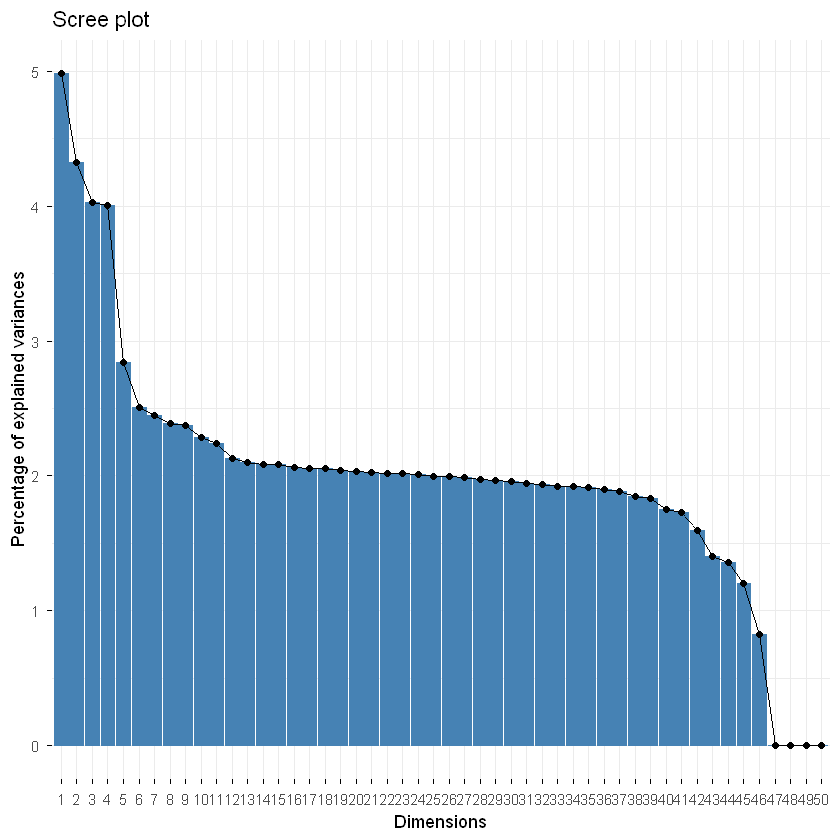

In [ ]:
fviz_screeplot(df.mca, addlabels = FALSE,ncp = 54)

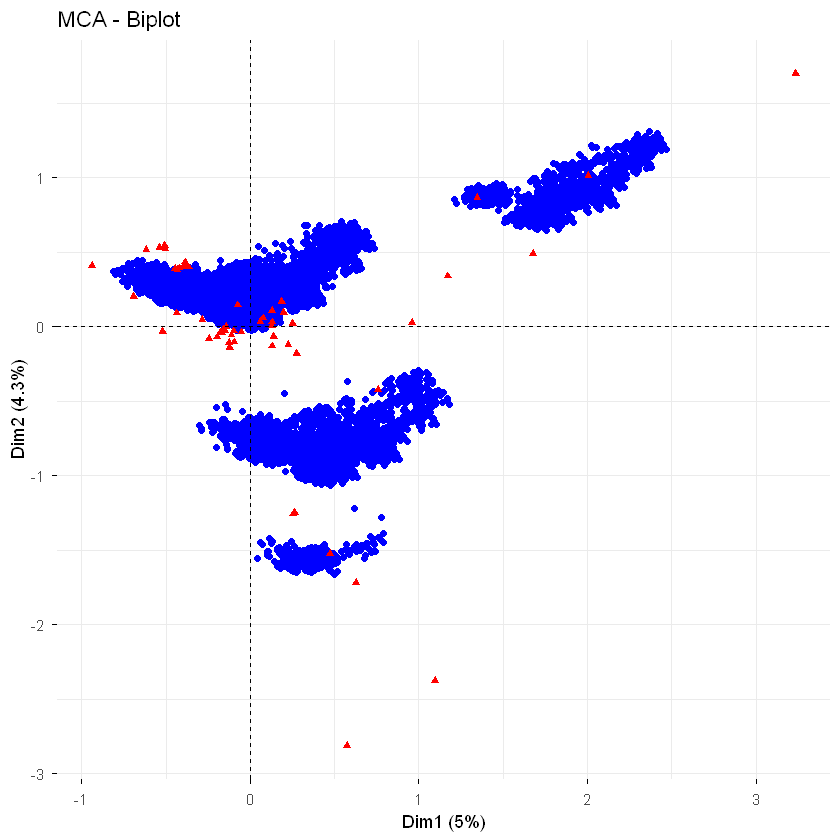

In [ ]:
fviz_mca_biplot(df.mca, label = "var", repel = TRUE, ggtheme = theme_minimal())

In [ ]:
fviz_contrib(df.mca, choice = "var", axes = 1, top = 10)
fviz_contrib(df.mca, choice = "var", axes = 2, top = 10)

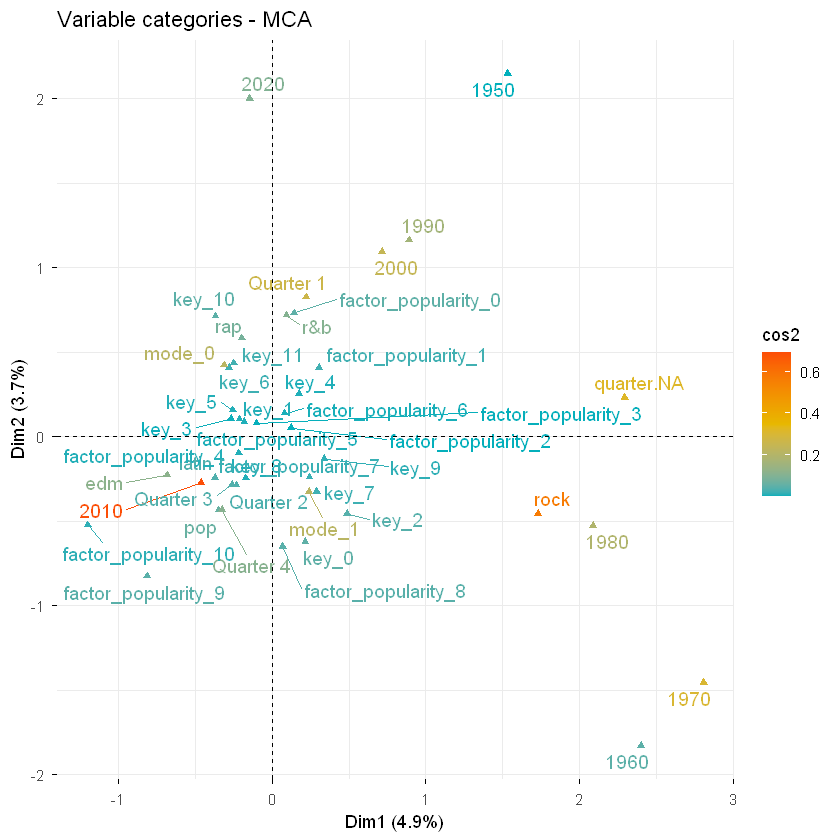

In [ ]:
fviz_mca_var(df.mca, col.var = "cos2", gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"), repel = TRUE)

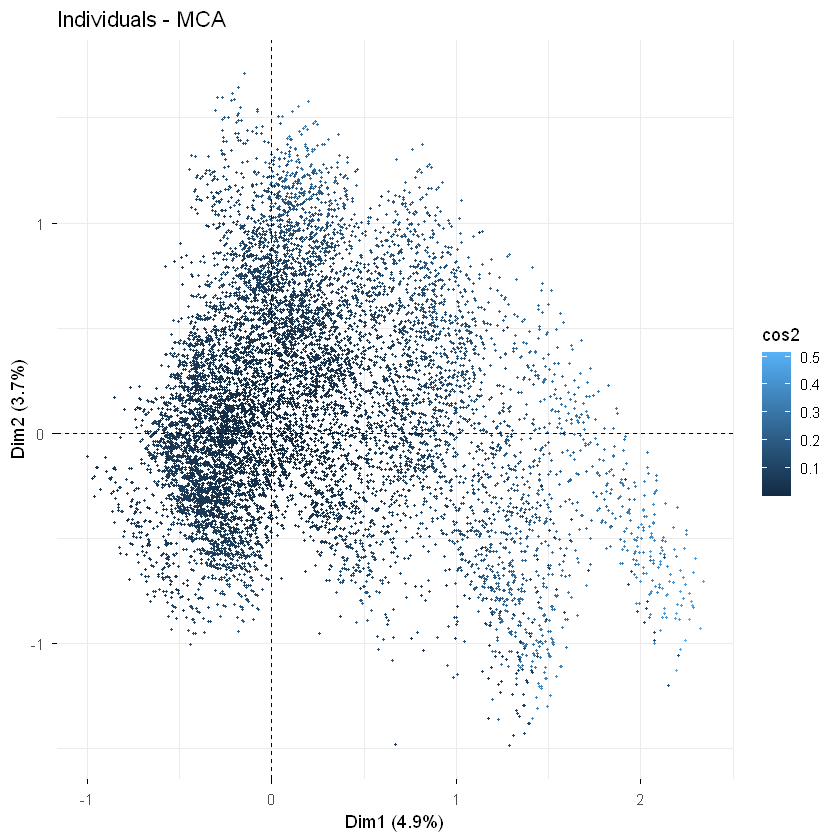

In [ ]:
fviz_mca_ind(df.mca, col.ind = "cos2", label = "none", pointsize = 0.5, ggtheme = theme_minimal())

In [ ]:
fviz_mca_ind(df.mca, col.ind = cat_df.sub$playlist_genre,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

In [ ]:
table(df$playlist_genre, df$year) %>% 
  prop.table(margin = 1) %>% 
  round(2)

In [ ]:
fviz_mca_ind(df.mca, col.ind = cat_df.sub$factor_popularity,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

### MCA sans les variables temporelles

In [ ]:
cat_df.sans_year <- cat_df.sub %>% dplyr::select(-year, -quarter)
df.mca2 <- MCA(cat_df.sans_year, graph = FALSE)
fviz_mca_biplot(df.mca2, label = "var", repel = TRUE)

In [ ]:
fviz_contrib(df.mca2, choice = "var", axes = 1, top = 10)
fviz_contrib(df.mca2, choice = "var", axes = 2, top = 10)

In [ ]:
fviz_mca_var(df.mca2, col.var = "cos2",
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE, ggtheme = theme_minimal())

In [ ]:
fviz_mca_ind(df.mca2, col.ind = cat_df.sans_year$playlist_genre,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

In [ ]:
fviz_mca_ind(df.mca2, col.ind = cat_df.sans_year$factor_popularity,
             label = "none", pointsize = 0.5,
             addEllipses = TRUE,
             ggtheme = theme_minimal())

## 5.NMF

In [4]:
library(NMF)

nmf_vars <- c('danceability','energy','loudness','speechiness',
              'acousticness','liveness','valence','tempo','duration_ms')
data_nmf <- df %>%
  dplyr::select(all_of(nmf_vars)) %>%
  distinct() %>%
  na.omit()

# Normalisation Min-Max → valeurs dans [0, 1]
# (obligatoire pour NMF : toutes valeurs >= 0)
min_max_scale <- function(x) (x - min(x)) / (max(x) - min(x))
data_nmf_scaled <- as.matrix(apply(data_nmf, 2, min_max_scale))

# Petite valeur epsilon pour éviter les zéros stricts
data_nmf_scaled[data_nmf_scaled == 0] <- 1e-10

cat("Dimensions :", dim(data_nmf_scaled), "\n")
cat("Min :", min(data_nmf_scaled), "| Max :", max(data_nmf_scaled), "\n")

Warning message:
"le package 'NMF' a été compilé avec la version R 4.5.3"
Le chargement a nécessité le package : registry

Warning message:
"le package 'registry' a été compilé avec la version R 4.5.2"
Le chargement a nécessité le package : rngtools

Warning message:
"le package 'rngtools' a été compilé avec la version R 4.5.3"
NMF - BioConductor layer [OK] | Shared memory capabilities [NO: windows] | Cores 2/2


Attachement du package : 'NMF'


L'objet suivant est masqué depuis 'package:generics':

    fit




Dimensions : 27632 9 
Min : 1e-10 | Max : 1 


In [6]:

set.seed(42)
n_nmf <- 5000
idx_nmf <- sample(nrow(data_nmf_scaled), n_nmf)
data_nmf_scaled_sub <- data_nmf_scaled[idx_nmf, ]

nmf_estim <- NMF::nmf(data_nmf_scaled_sub, rank = 2:6,
                      method = "brunet",
                      nrun = 10,
                      .options = "v")

Compute NMF rank= 2  ... + measures ... OK
Compute NMF rank= 3  ... + measures ... OK
Compute NMF rank= 4  ... + measures ... OK
Compute NMF rank= 5  ... + measures ... OK
Compute NMF rank= 6  ... + measures ... OK


Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the NMF package.
  Please report the issue to the authors."


,method,seed,rng,metric,rank,sparseness.basis,sparseness.coef,rss,evar,silhouette.coef,silhouette.basis,residuals,niter,cpu,cpu.all,nrun,cophenetic,dispersion,silhouette.consensus
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,brunet,random,4,KL,2,0.1968368,0.4460269,722.7022,0.9451336,0.8888889,1.0000000,936.6705,470,NA,NA,10,1.0000000,1.0000000,0.8888889
3,brunet,random,1,KL,3,0.1863782,0.4609965,506.9624,0.9615122,0.7028405,0.6944580,655.0490,540,NA,NA,10,0.9768746,0.6256790,0.6816125
4,brunet,random,3,KL,4,0.1937478,0.5453348,368.3075,0.9720387,0.5617077,0.5266169,432.8346,790,NA,NA,10,0.9861346,0.8370370,0.6337317
5,brunet,random,2,KL,5,0.2314356,0.5749174,278.8013,0.9788339,0.4577884,0.4618914,248.1474,450,NA,NA,10,0.9937191,0.8962963,0.4746032
6,brunet,random,3,KL,6,0.2158165,0.6743508,171.6744,0.9869668,0.3248689,0.3885419,155.7765,610,NA,NA,10,0.9610180,0.8558025,0.3899571


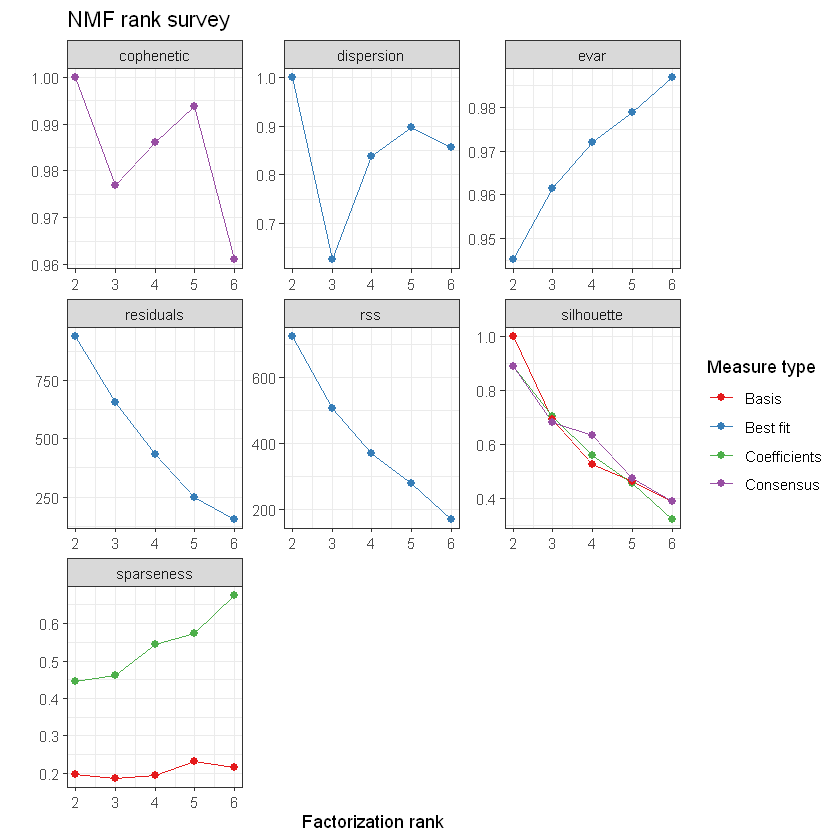

In [7]:
plot(nmf_estim)
summary(nmf_estim)

# Supprimer les dossiers temporaires NMF
tmp_dirs <- list.dirs(path = ".", recursive = FALSE)
nmf_dirs <- tmp_dirs[grepl("NMF", tmp_dirs)]
unlink(nmf_dirs, recursive = TRUE)
cat("Dossiers NMF supprimés :", length(nmf_dirs), "\n")


Bien que r=3 présente un Cophenetic légèrement supérieur, r=4 a été retenu car chaque composante présente une variable clairement dominante, rendant les profils musicalement interprétables.

In [8]:

r_optimal <- 4  

set.seed(42)
nmf_model <- NMF::nmf(data_nmf_scaled, rank = r_optimal,
                      method = "brunet",
                      nrun = 30)

cat("Erreur de reconstruction :", nmf_model@residuals, "\n")

Erreur de reconstruction : 2399.365 


In [9]:

# W (n × r) : coordonnées des individus dans l'espace NMF
# H (r × p) : profils des composantes (contribution des variables)

W <- basis(nmf_model)    # individus
H <- coef(nmf_model)     # variables

colnames(W) <- paste0("NMF", 1:r_optimal)
rownames(H) <- paste0("NMF", 1:r_optimal)
colnames(H) <- nmf_vars

cat("W (individus) :", dim(W), "\n")
cat("H (variables) :", dim(H), "\n")

W (individus) : 27632 4 
H (variables) : 4 9 


Nb subgenres : 27632 
Nb lignes W : 27632 


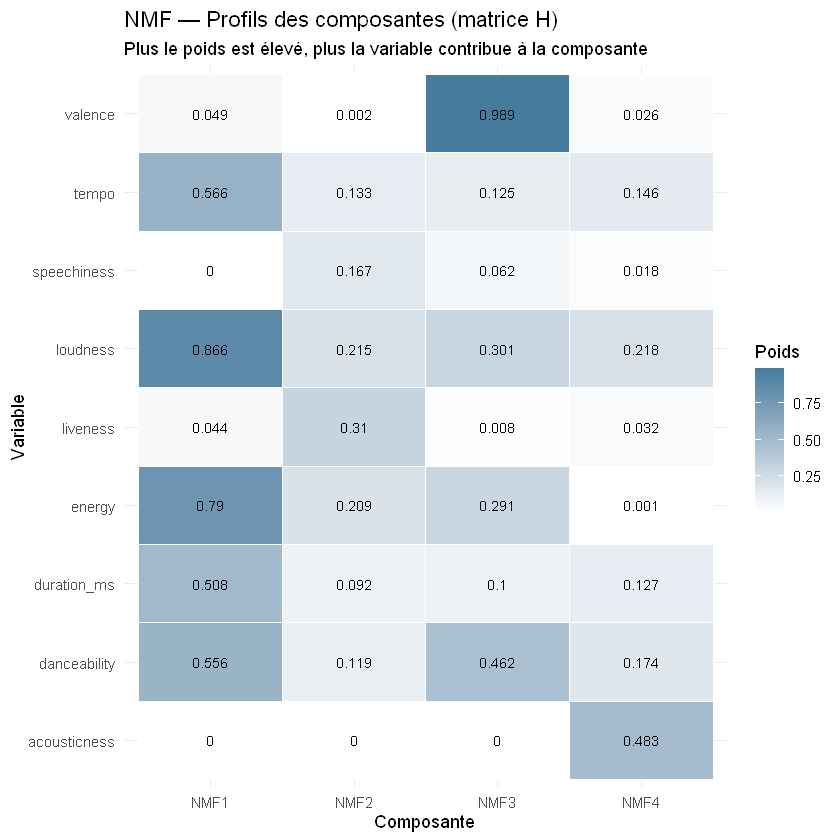

In [10]:

# ── Interprétation des composantes : profils variables ───────────────────────
# Heatmap de H : quelles variables contribuent à chaque composante ?

H_df <- as.data.frame(t(H))
H_df$variable <- rownames(H_df)
H_long <- tidyr::pivot_longer(H_df, -variable,
                               names_to = "composante",
                               values_to = "poids")

ggplot(H_long, aes(x = composante, y = variable, fill = poids)) +
  geom_tile(color = "white") +
  geom_text(aes(label = round(poids, 3)), size = 3) +
  scale_fill_gradient(low = "white", high = "#457B9D") +
  labs(title = "NMF — Profils des composantes (matrice H)",
       x = "Composante", y = "Variable", fill = "Poids") +
  theme_minimal()


subgenres <- df %>%
  dplyr::select(all_of(nmf_vars), playlist_subgenre) %>%
  na.omit() %>%
  distinct(across(all_of(nmf_vars)), .keep_all = TRUE) %>%
  pull(playlist_subgenre)

cat("Nb subgenres :", length(subgenres), "\n")
cat("Nb lignes W :", nrow(W), "\n")

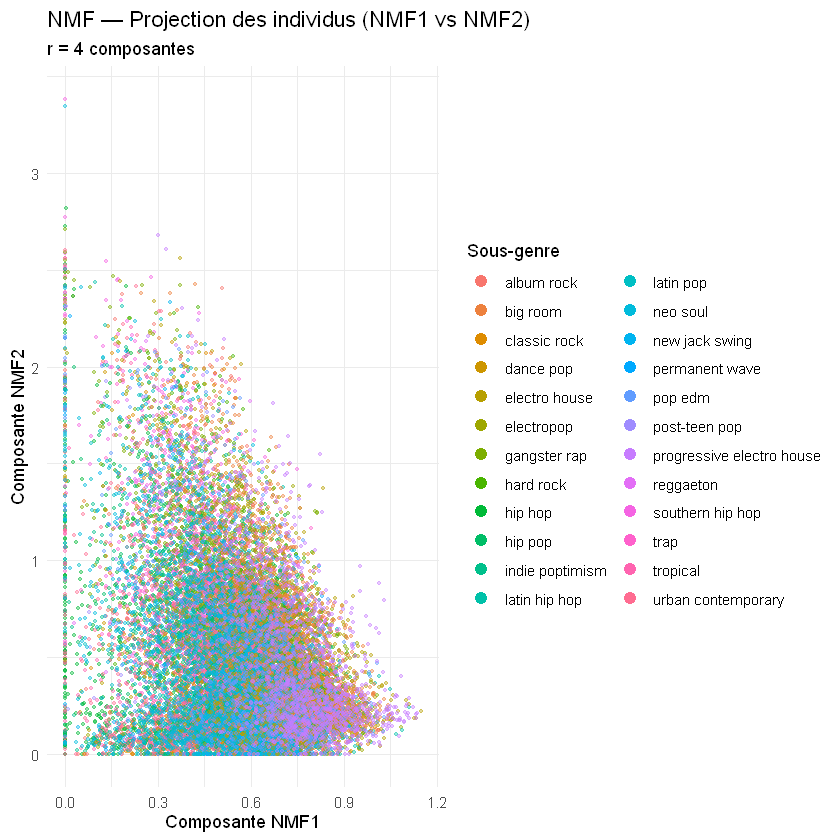

In [11]:

# ── Visualisation des individus (W) colorés par playlist_subgenre ────────────
# On projette sur les 2 premières composantes NMF



df_W <- as.data.frame(W)
df_W$subgenre <- subgenres

ggplot(df_W, aes(x = NMF1, y = NMF2, color = subgenre)) +
  geom_point(alpha = 0.4, size = 0.8) +
  labs(title = "NMF — Projection des individus (NMF1 vs NMF2)",
       subtitle = paste("r =", r_optimal, "composantes"),
       x = "Composante NMF1", y = "Composante NMF2",
       color = "Sous-genre") +
  theme_minimal() +
  guides(color = guide_legend(override.aes = list(size = 3, alpha = 1)))

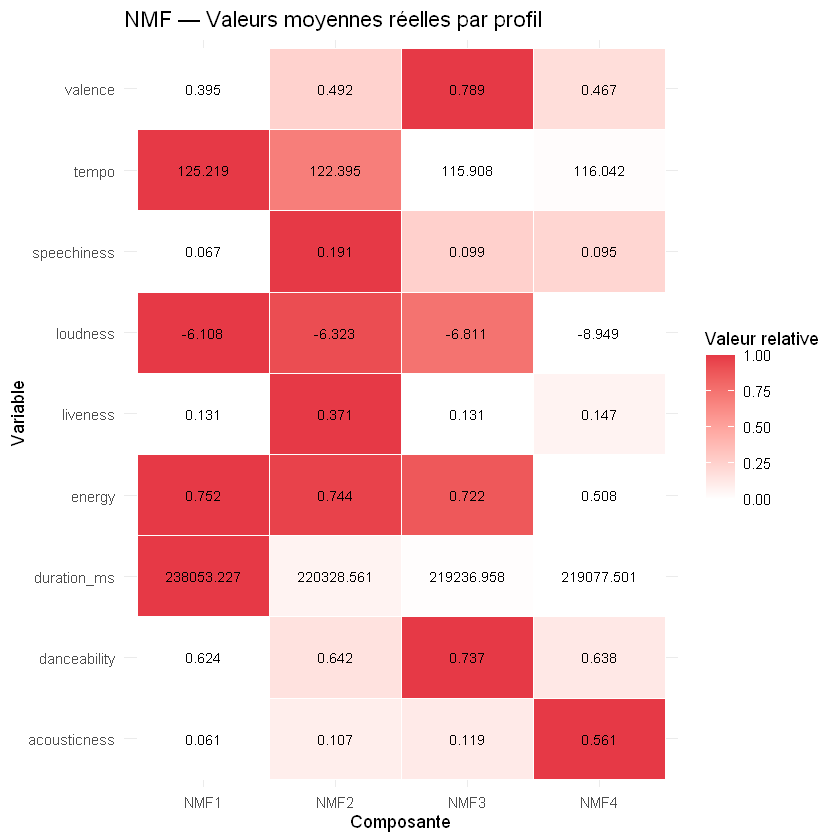

In [15]:
#### coloration des valeurs moyennes par leurs valeurs
df %>%
  dplyr::select(dplyr::all_of(nmf_vars)) %>%
  na.omit() %>%
  dplyr::distinct(dplyr::across(dplyr::all_of(nmf_vars)), .keep_all = TRUE) %>%
  mutate(composante = df_W$composante_dominante) %>%
  group_by(composante) %>%
  summarise(across(all_of(nmf_vars), ~round(mean(.x, na.rm=TRUE), 3))) %>%
  pivot_longer(-composante, names_to = "variable", values_to = "valeur") %>%
  group_by(variable) %>%
  mutate(valeur_normalisee = (valeur - min(valeur)) / (max(valeur) - min(valeur))) %>%
  ungroup() %>%
  ggplot(aes(x = composante, y = variable, fill = valeur_normalisee)) +
  geom_tile(color = "white") +
  geom_text(aes(label = valeur), size = 3) +
  scale_fill_gradient(low = "white", high = "#E63946") +
  labs(title    = "NMF — Valeurs moyennes réelles par profil",
       x = "Composante", y = "Variable", fill = "Valeur relative") +
  theme_minimal()

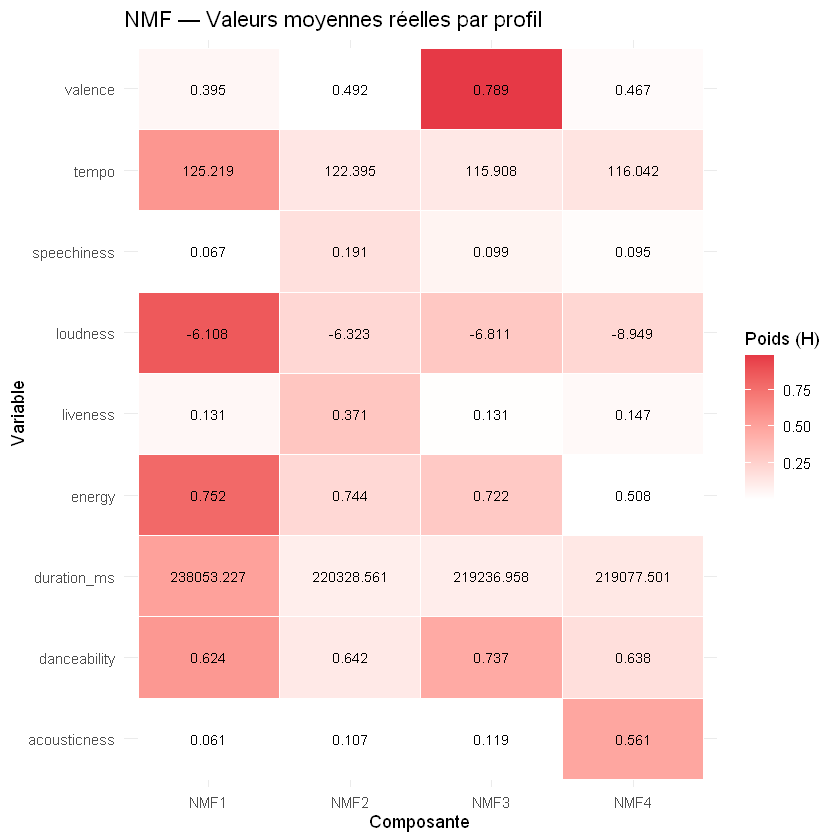

In [16]:
#### Coloration des valeurs moyennes par les poids
# Matrice H en format long
H_long <- as.data.frame(t(H)) %>%
  rownames_to_column("variable") %>%
  pivot_longer(-variable, names_to = "composante", values_to = "poids")

# Valeurs moyennes réelles
df %>%
  dplyr::select(dplyr::all_of(nmf_vars)) %>%
  na.omit() %>%
  dplyr::distinct(dplyr::across(dplyr::all_of(nmf_vars)), .keep_all = TRUE) %>%
  mutate(composante = df_W$composante_dominante) %>%
  group_by(composante) %>%
  summarise(across(all_of(nmf_vars), ~round(mean(.x, na.rm=TRUE), 3))) %>%
  pivot_longer(-composante, names_to = "variable", values_to = "valeur") %>%
  left_join(H_long, by = c("composante", "variable")) %>%
  ggplot(aes(x = composante, y = variable, fill = poids)) +
  geom_tile(color = "white") +
  geom_text(aes(label = valeur), size = 3) +
  scale_fill_gradient(low = "white", high = "#E63946") +
  labs(title    = "NMF — Valeurs moyennes réelles par profil",
       x = "Composante", y = "Variable", fill = "Poids (H)") +
  theme_minimal()

| NMF | profil musical |
|-----------|-----------|
| NMF1   |       Musique forte, très énergique et  bpm élevé    |
| NMF2   |     Musique live et énergique      |
| NMF3   |       Musique joyeuse, dansante et plutot énergique    |
| NMF4   |   Musique acoustique et calme        |

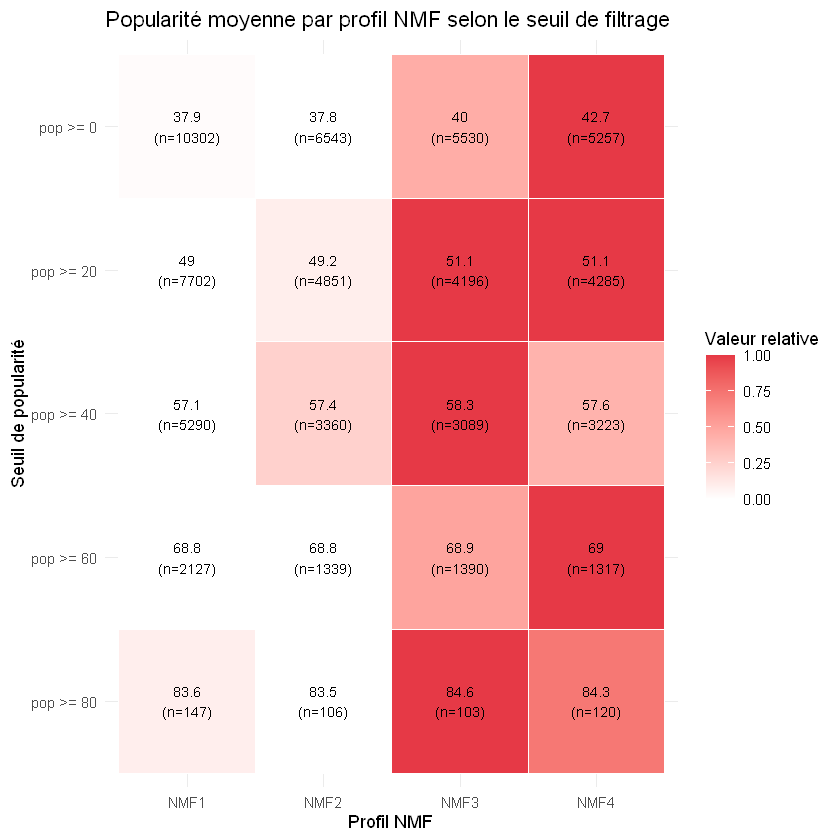

In [17]:

# Popularité par profil pour différents seuils
seuils <- c(0, 20, 40, 60, 80)
popularite <- df %>%
  dplyr::select(dplyr::all_of(nmf_vars), track_popularity) %>%
  na.omit() %>%
  dplyr::distinct(dplyr::across(dplyr::all_of(nmf_vars)), .keep_all = TRUE) %>%
  dplyr::pull(track_popularity)

df_W$popularite <- popularite
df_W$composante_dominante <- paste0("NMF", apply(W, 1, which.max))
map_dfr(seuils, function(s) {
  df_W %>%
    filter(popularite >= s) %>%
    group_by(composante_dominante) %>%
    summarise(
      popularite_moy = round(mean(popularite, na.rm = TRUE), 1),
      n              = n(),
      .groups        = "drop"
    ) %>%
    mutate(seuil = paste0("pop >= ", s))
}) %>%
  group_by(seuil) %>%
  mutate(valeur_normalisee = (popularite_moy - min(popularite_moy)) / 
                             (max(popularite_moy) - min(popularite_moy))) %>%
  ungroup() %>%
  ggplot(aes(x = composante_dominante, y = seuil, fill = valeur_normalisee)) +
  geom_tile(color = "white") +
  geom_text(aes(label = paste0(popularite_moy, "\n(n=", n, ")")), size = 3) +
  scale_fill_gradient(low = "white", high = "#E63946") +
  scale_y_discrete(limits = paste0("pop >= ", rev(seuils))) +
  labs(title    = "Popularité moyenne par profil NMF selon le seuil de filtrage",
       x = "Profil NMF", y = "Seuil de popularité", fill = "Valeur relative") +
  theme_minimal()

| NMF | popularité  |
|-----------|-----------|
| NMF1   |     en général peu populaire, sûrement très dilué (le plus d'observation) mais est plus populaire que la musique live pour les très artistes connus (pop>=80)    |
| NMF2   |     peu populaire en comparant à NMF3 et 4, mais l'écart devient de plus en plus faible à mesure qu'on regarde les popularités élevés -> les artistes déjà populaires ont des concerts lives qui attirent plus qu'un artiste méconnu      |
| NMF3   |      Toujours très populaire, correspond relativement bien à la teen pop qui est en général un genre populaire (voir AFC)   |
| NMF4   |   Très populaire aussi en général, correspond aux musique qu'on écoute pendant que l'on travaille/se repose        |

# III. Clustering

Au de-là 

## 1. K-means

In [12]:
# On normalise les données, et supprime la variable de popularité
 
vocal_df <- num_df[, -which(names(num_df) == "track_popularity")]
df_scaled <- scale(vocal_df)

# Sous-échantillon
set.seed(42)
sample_idx <- sample(nrow(df_scaled), 5000)

quanti_sample <- df_scaled[sample_idx, ]  # définition de quanti_sample (scaled)
spotify_sample <- df[sample_idx, ]

In [13]:
summary(quanti_sample)

  danceability          energy             valence             tempo            sqrt_speechiness    sqrt_acousticness 
 Min.   :-3.55649   Min.   :-3.717871   Min.   :-2.17845   Min.   :-3.1104216   Min.   :-1.151549   Min.   :-1.31963  
 1st Qu.:-0.60659   1st Qu.:-0.655829   1st Qu.:-0.77455   1st Qu.:-0.7783801   1st Qu.:-0.755481   1st Qu.:-0.85829  
 Median : 0.12059   Median : 0.117992   Median : 0.02771   Median : 0.0382935   Median :-0.380865   Median :-0.20801  
 Mean   : 0.01003   Mean   :-0.007881   Mean   : 0.01453   Mean   : 0.0005267   Mean   :-0.004022   Mean   : 0.00079  
 3rd Qu.: 0.73801   3rd Qu.: 0.778737   3rd Qu.: 0.80543   3rd Qu.: 0.4990347   3rd Qu.: 0.486439   3rd Qu.: 0.68144  
 Max.   : 2.21982   Max.   : 1.643836   Max.   : 2.02055   Max.   : 3.6732842   Max.   : 4.746831   Max.   : 2.59552  
 sqrt_duration_ms    log_liveness      cqrt_loudness     
 Min.   :-4.28478   Min.   :-1.30799   Min.   :-3.95255  
 1st Qu.:-0.60335   1st Qu.:-0.67699   1st Qu.:-0.6

Afin de déterminer le nombre de clusters optimal, nous appliquons deux méthodes : la méthode du coude (WSS) qui mesure l'inertie intra-classe, et la méthode de la silhouette qui évalue la qualité de séparation des clusters. Ces deux méthodes sont appliquées sur un sous-échantillon de 5000 observations pour des raisons de temps de calcul.

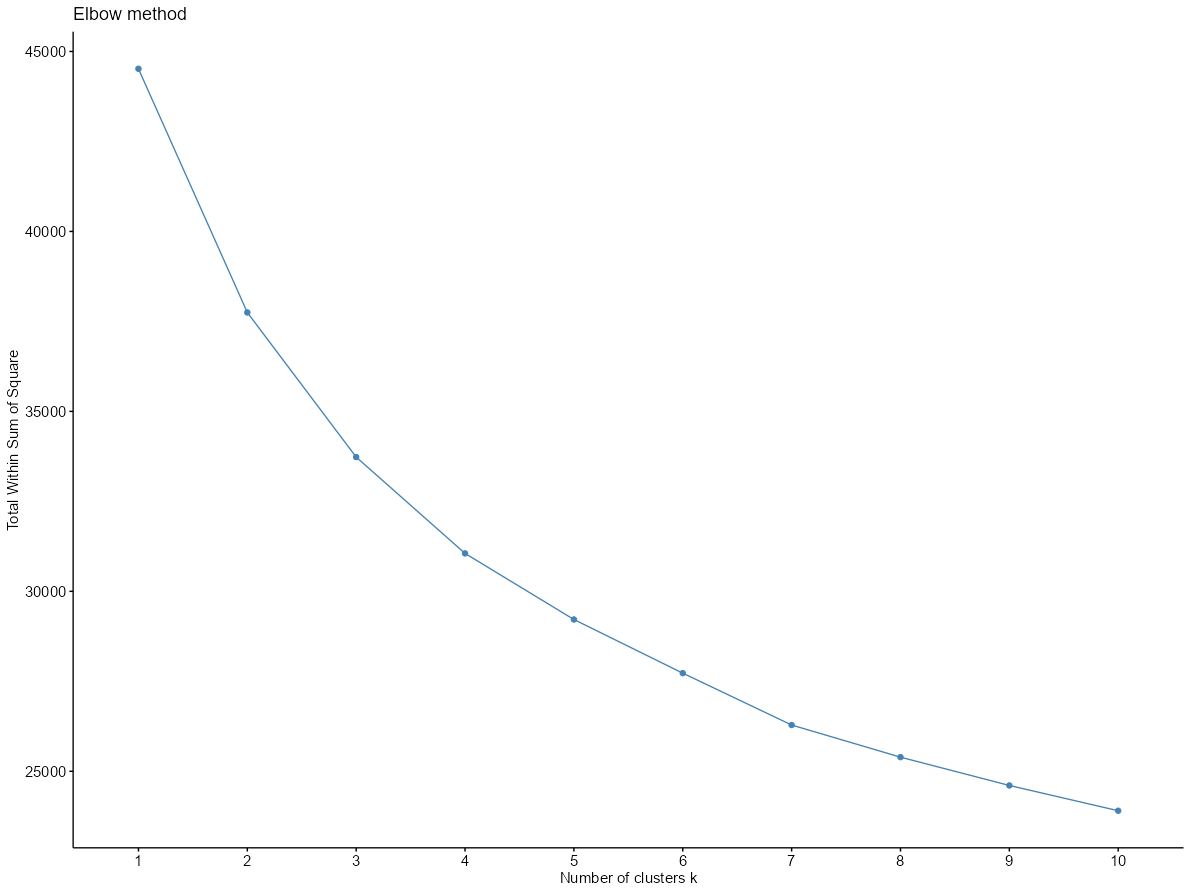

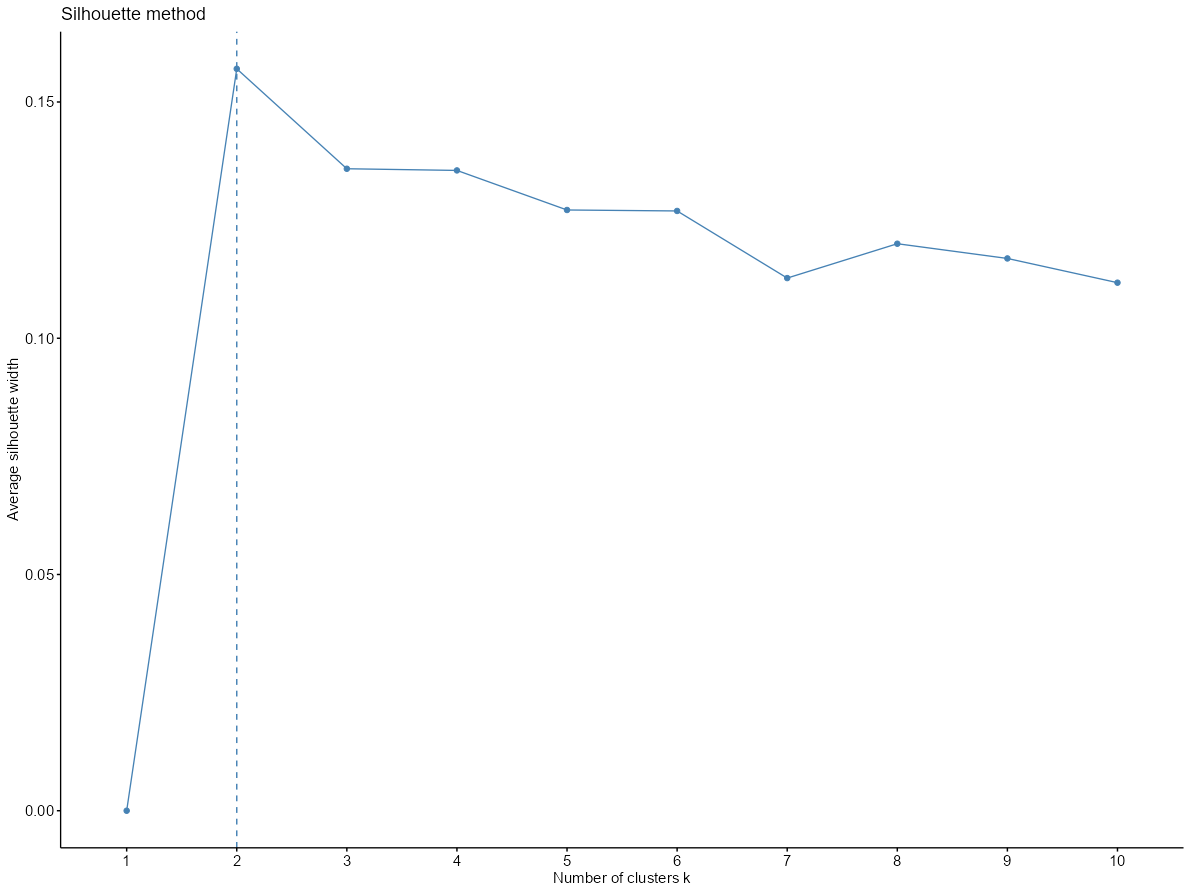

In [14]:
# Choix du nb de clusters k : elbow + silhouette
fviz_nbclust(quanti_sample, kmeans, method = "wss", k.max = 10) +
  labs(title = "Elbow method")
fviz_nbclust(quanti_sample, kmeans, method = "silhouette", k.max = 10) +
  labs(title = "Silhouette method")

Le score silhouette reste très faible (< 0.2) pour tout k, et le graphe de l'inertie intra-classe pas particulièrement informatif. En l'absence de structure naturelle évidente, nous choisissons k = 6 à priori, correspondant aux 6 genres musicaux présents dans le jeu de données.

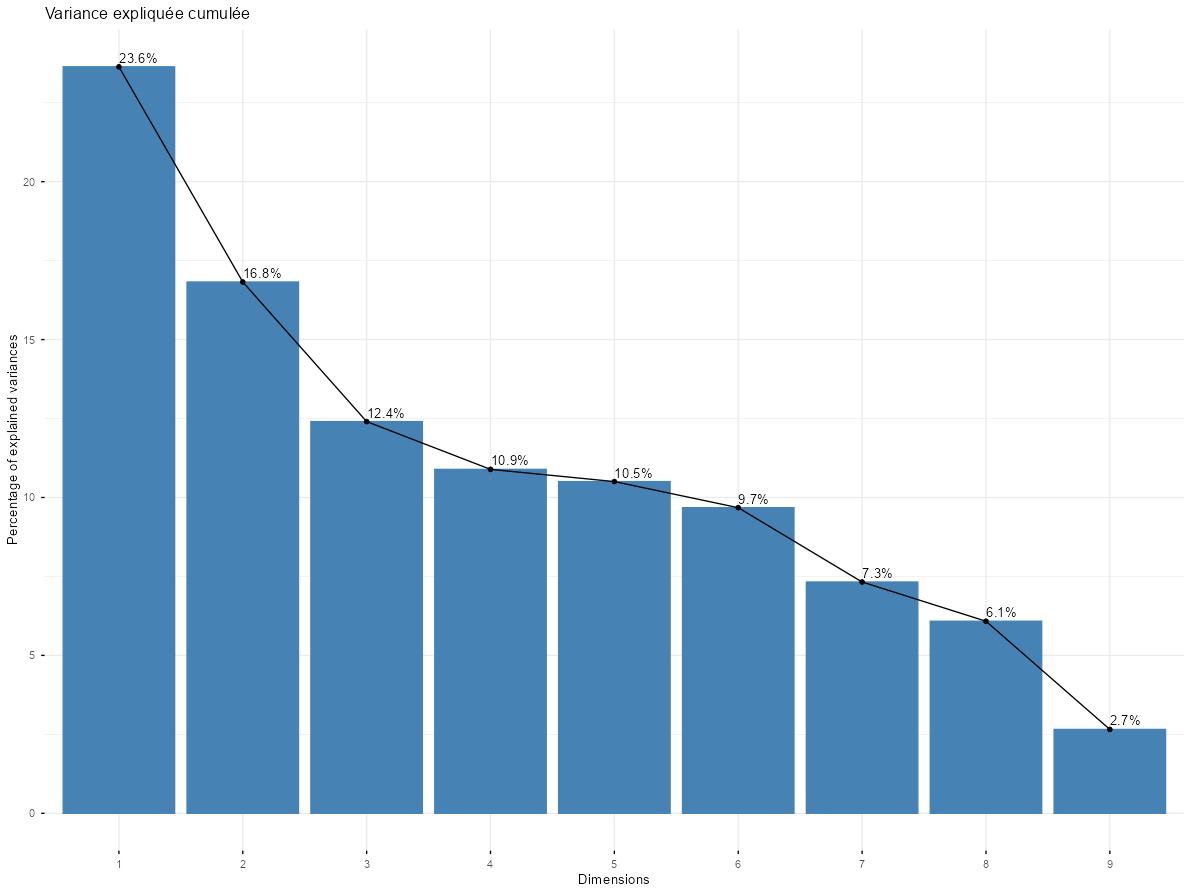

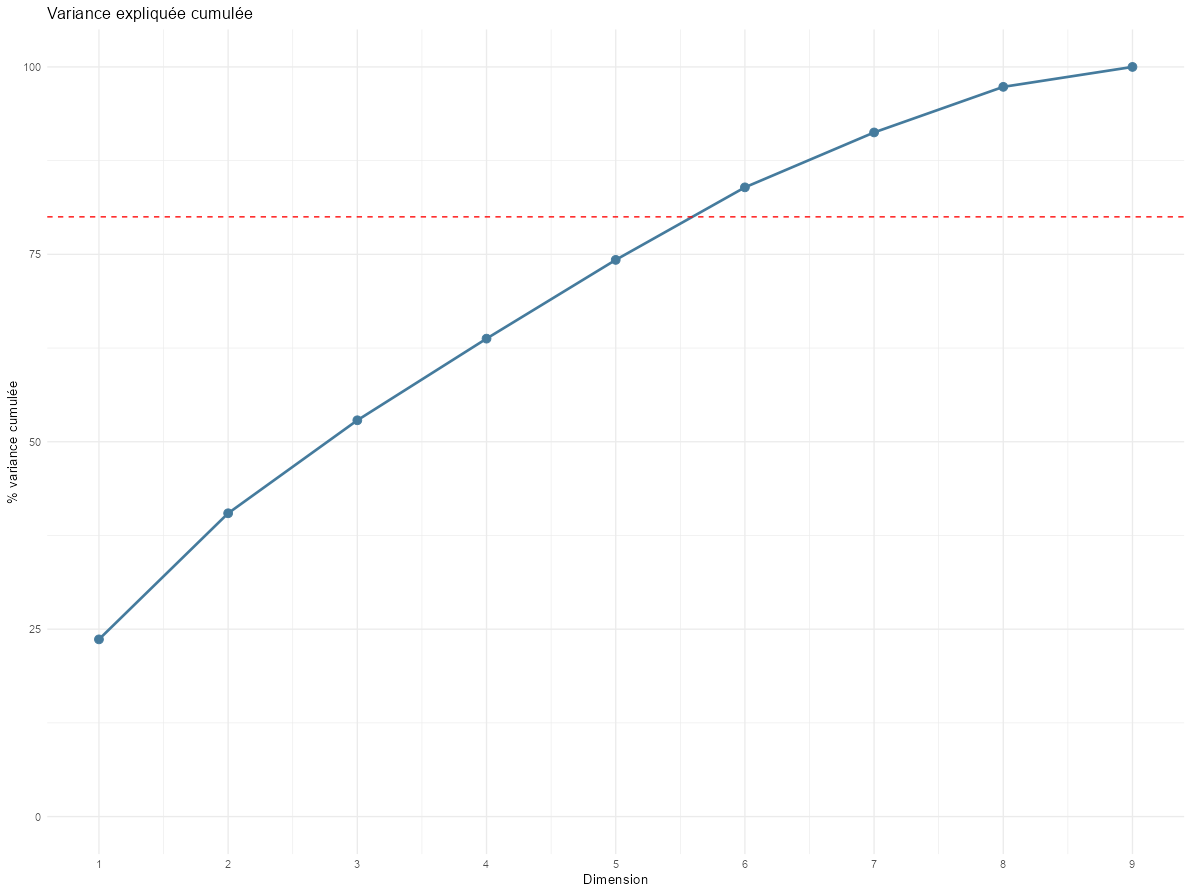

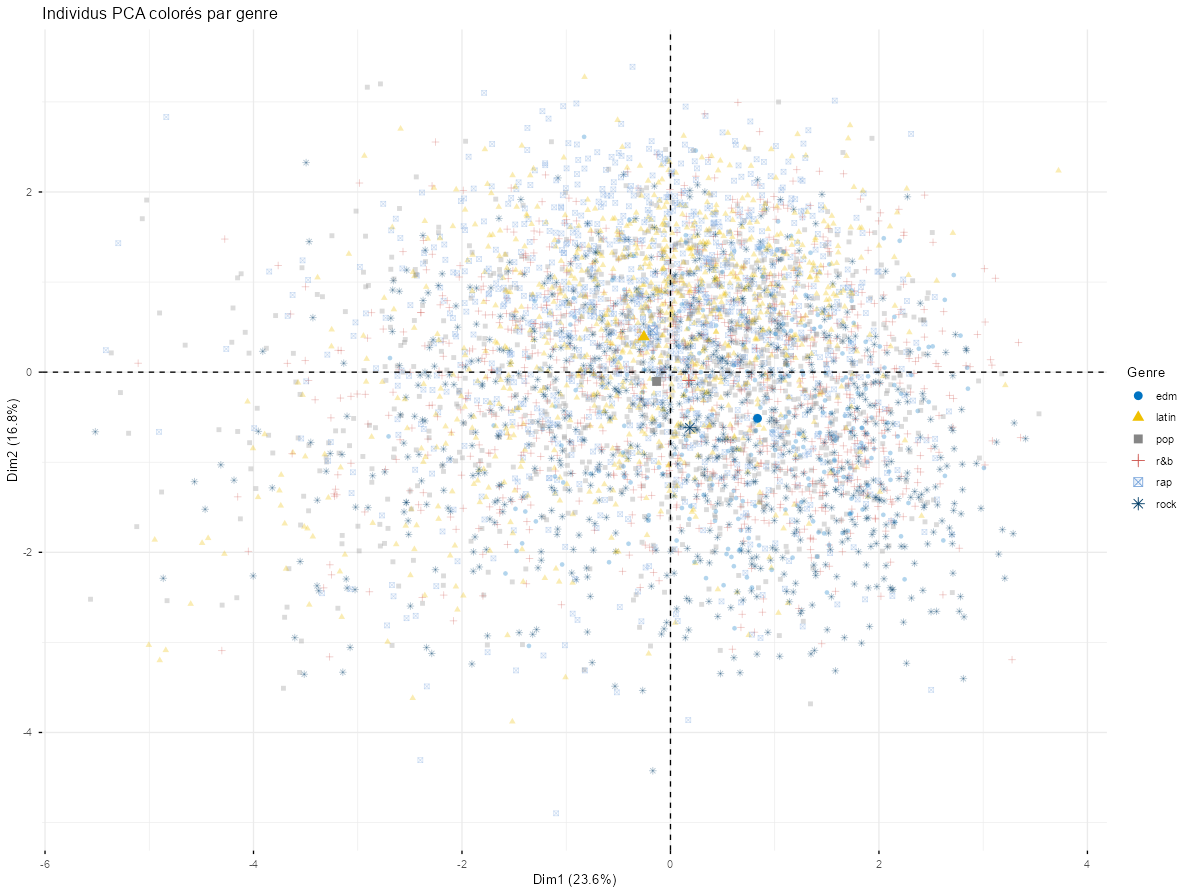

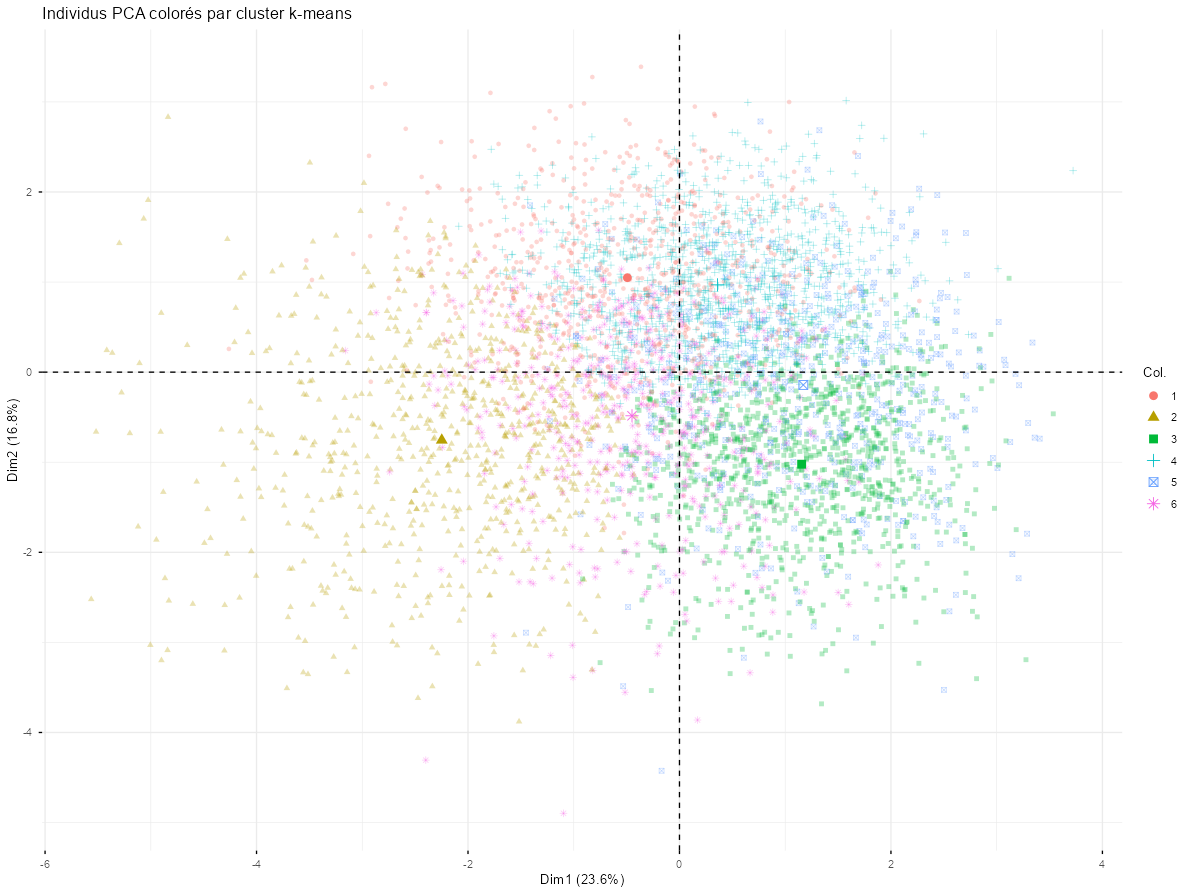

In [15]:
pca_c <- PCA(quanti_sample, ncp = 6, graph = FALSE)
coords_pca_c <- pca_c$ind$coord

set.seed(42)
km <- kmeans(coords_pca_c, centers = 6, nstart = 25)
spotify_sample$cluster_km <- as.factor(km$cluster)

# Cumulative explained variance
fviz_eig(pca_c, addlabels = TRUE, cumulative = TRUE) +
  labs(title = "Variance expliquée cumulée")

var_cum <- cumsum(pca_c$eig[, 2])
df_eig <- data.frame(
  dim = 1:length(var_cum),
  variance_cumulee = var_cum
)

ggplot(df_eig, aes(x = dim, y = variance_cumulee)) +
  geom_line(color = "#457B9D", linewidth = 1) +
  geom_point(color = "#457B9D", size = 3) +
  geom_hline(yintercept = 80, linetype = "dashed", color = "red") +
  scale_x_continuous(breaks = 1:nrow(df_eig)) +
  scale_y_continuous(limits = c(0, 100)) +
  labs(title = "Variance expliquée cumulée",
       x = "Dimension", y = "% variance cumulée") +
  theme_minimal()



# Cercle des corrélations Dim1-Dim2
#fviz_pca_var(pca_c, axes = c(1, 2),
 #            col.var = "contrib",
  #           gradient.cols = c("turquoise", "orange", "red"),
   #          repel = TRUE) +
  #labs(title = "Variables - PCA Dim1 x Dim2")

# Coloré par genre pour voir si les clusters correspondent aux genres
fviz_pca_ind(pca_c,
             geom = "point",
             col.ind = spotify_sample$playlist_genre,
             alpha.ind = 0.3,
             palette = "jco",
             legend.title = "Genre",
             ggtheme = theme_minimal()) +
  labs(title = "Individus PCA colorés par genre")

# Coloré par cluster k-means
fviz_pca_ind(pca_c,
             geom = "point",
             col.ind = spotify_sample$cluster_km,
             alpha.ind = 0.3,
             ggtheme = theme_minimal()) +
  labs(title = "Individus PCA colorés par cluster k-means")

prop.table(table(spotify_sample$cluster_km, spotify_sample$playlist_genre), margin = 1)

df_plot <- data.frame(
  Dim1 = coords_pca_c[, 1],
  Dim2 = coords_pca_c[, 2],
  cluster = spotify_sample$cluster_km,
  genre = spotify_sample$playlist_genre
)


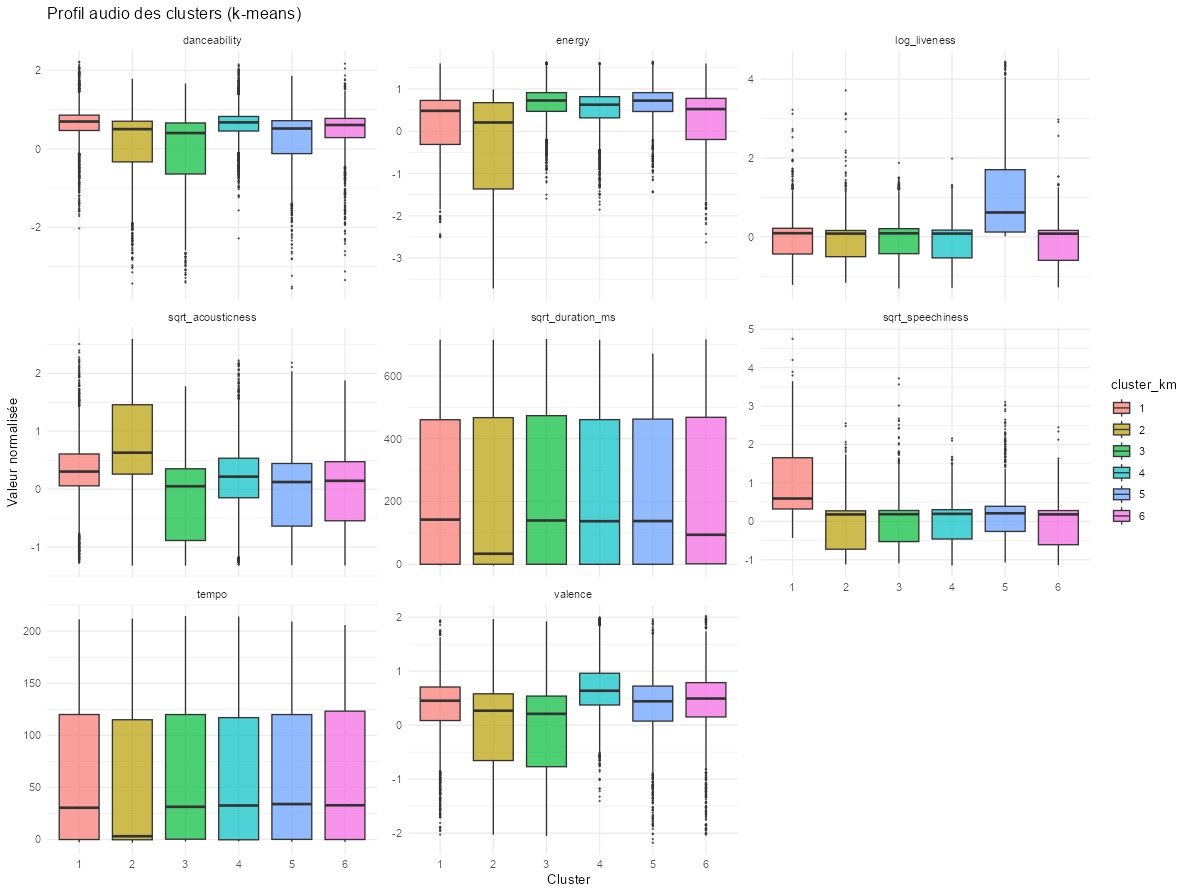

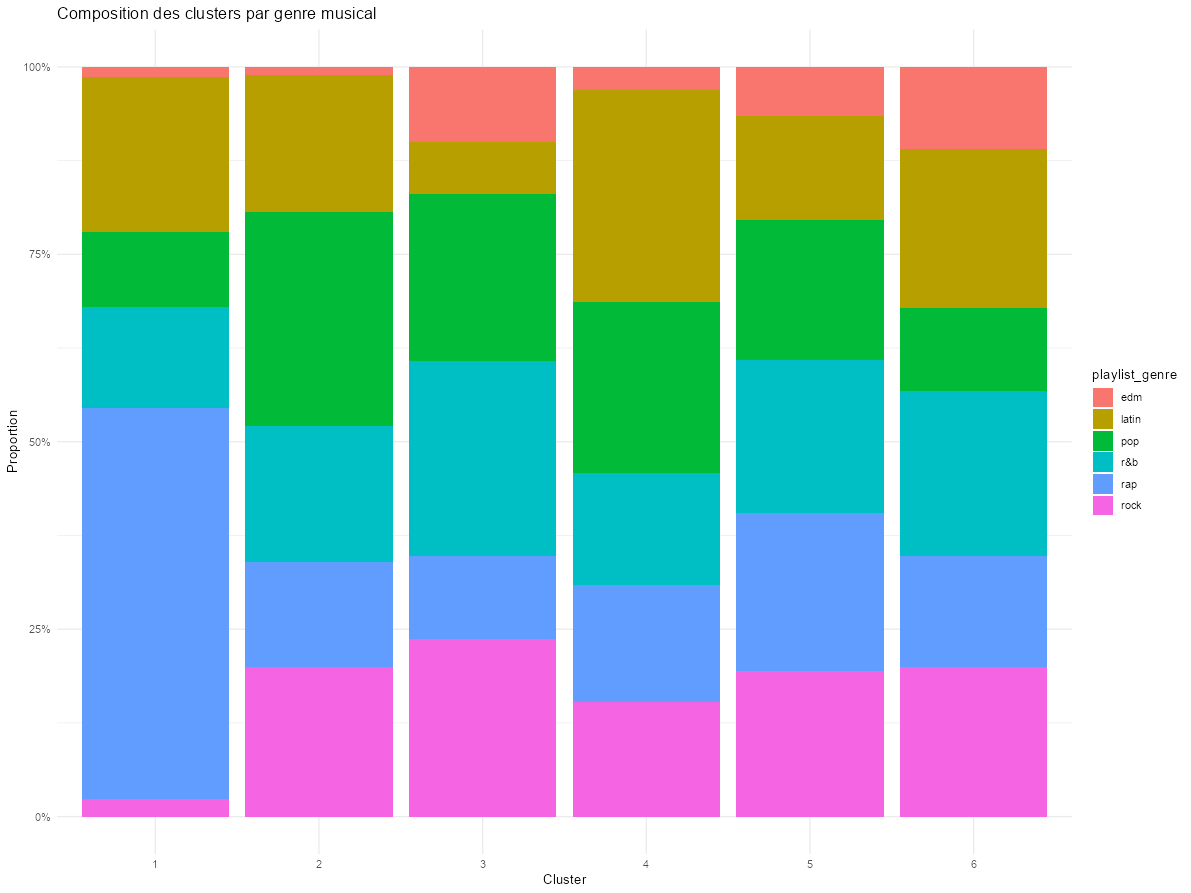

In [16]:
# Boxplots variables audio par cluster
vars_audio <- intersect(c("energy", "danceability", "valence", "sqrt_acousticness", "sqrt_speechiness", "tempo", "log_liveness", "loudness", "instrumentalness", "sqrt_duration_ms"), colnames(quanti_sample))

df_long <- cbind(spotify_sample, as.data.frame(quanti_sample)[, vars_audio]) %>%
  pivot_longer(cols = all_of(vars_audio),
               names_to = "variable",
               values_to = "valeur")

ggplot(df_long, aes(x = cluster_km, y = valeur, fill = cluster_km)) +
  geom_boxplot(outlier.size = 0.3, alpha = 0.7) +
  facet_wrap(~variable, scales = "free_y") +
  theme_minimal() +
  labs(title = "Profil audio des clusters (k-means)", x = "Cluster", y = "Valeur normalisée")

# Barplot genre par cluster
ggplot(spotify_sample, aes(x = cluster_km, fill = playlist_genre)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Composition des clusters par genre musical", y = "Proportion", x = "Cluster")

Le k-means ne parvient pas à retrouver les genres musicaux (ARI < 0.1). On applique ensuite la Classification Ascendante Hiérarchique (CAH) avec le critère de Ward sur un sous-échantillon, afin d'explorer la structure hiérarchique des données via le dendrogramme.

## 2. Classification Ascendante Hiérarchique (CAH)

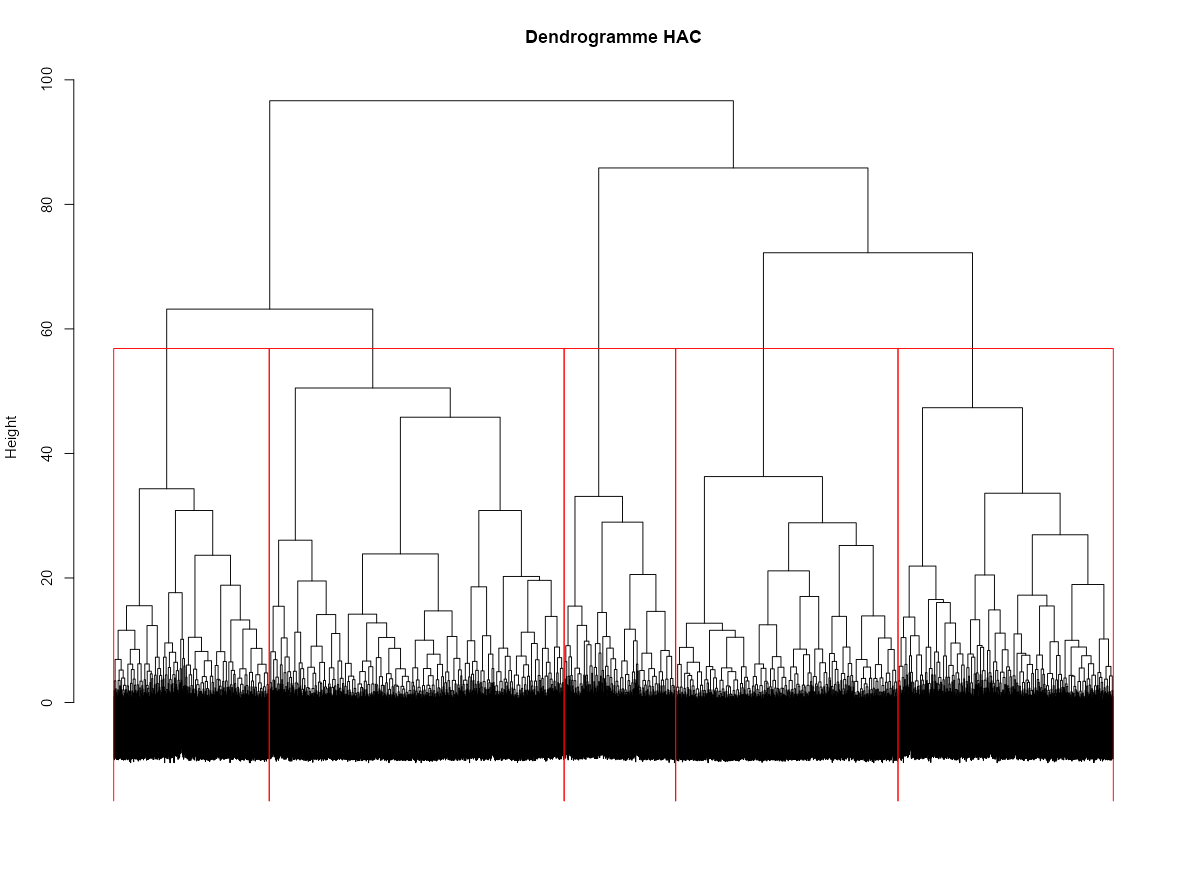

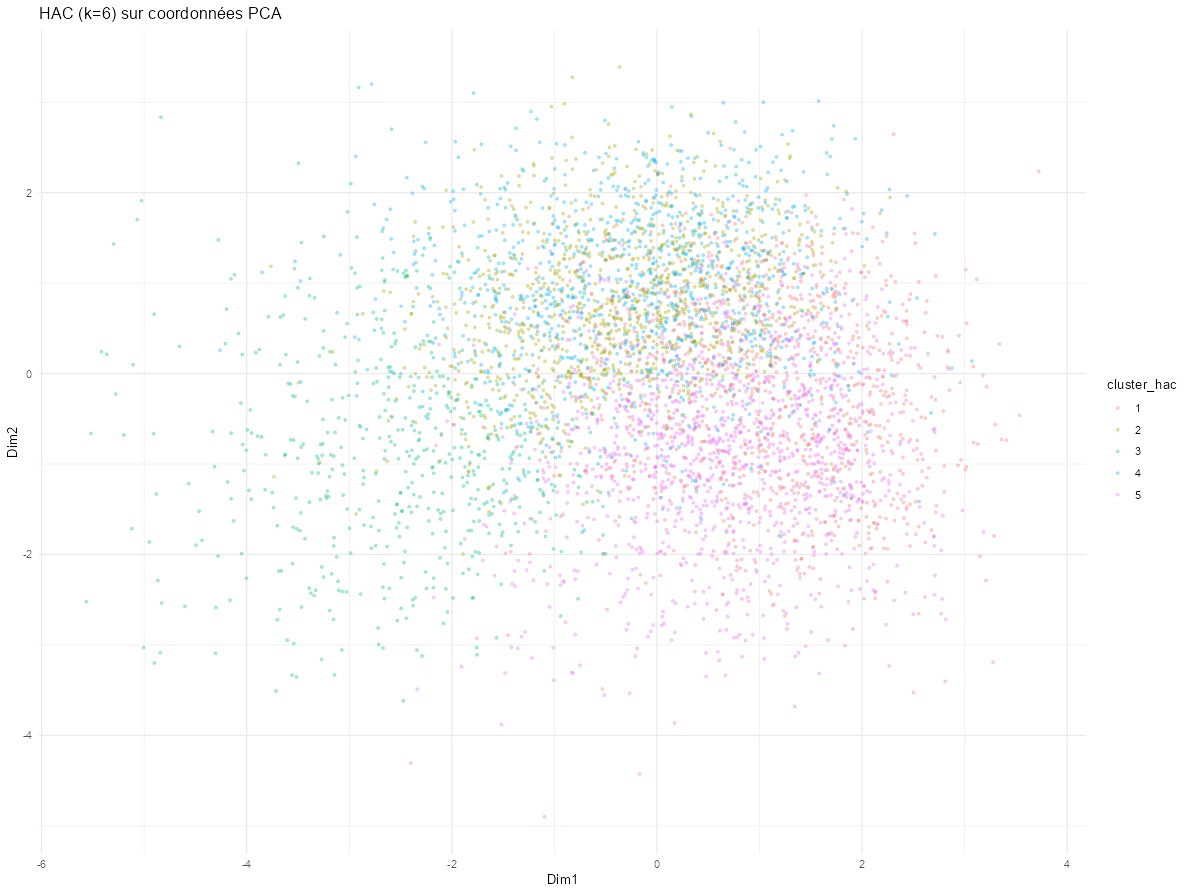

In [17]:

hac <- hclust(dist(coords_pca_c), method = "ward.D2")

# Dendrogramme
plot(hac, labels = FALSE, main = "Dendrogramme HAC", xlab = "", sub = "")
rect.hclust(hac, k = 5, border = "red")

# Couper en 6 clusters
spotify_sample$cluster_hac <- as.factor(cutree(hac, k = 5))

# Visualisation sur PCA
ggplot(df_plot %>% mutate(cluster_hac = spotify_sample$cluster_hac),
       aes(x = Dim1, y = Dim2, color = cluster_hac)) +
  geom_point(alpha = 0.3, size = 0.8) +
  theme_minimal() +
  labs(title = "HAC (k=6) sur coordonnées PCA")

In [18]:
# Comparaison HAC vs genre
ari_hac <- adjustedRandIndex(spotify_sample$cluster_hac, spotify_sample$playlist_genre)
cat("ARI (HAC vs genre) :", round(ari_hac, 3))

# Comparaison HAC vs k-means
ari_hac_km <- adjustedRandIndex(spotify_sample$cluster_hac, spotify_sample$cluster_km)
cat("ARI (HAC vs k-means) :", round(ari_hac_km, 3))

ARI (HAC vs genre) : 0.039ARI (HAC vs k-means) : 0.334

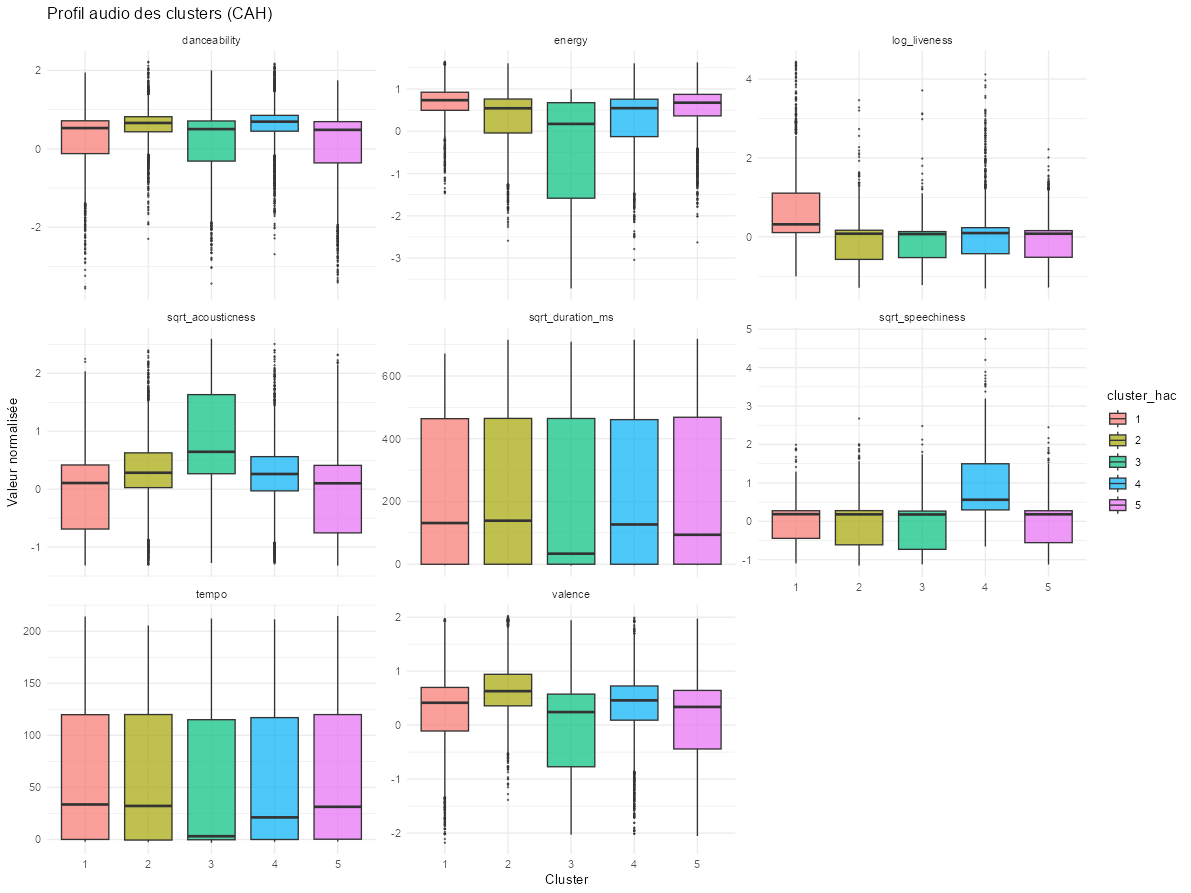

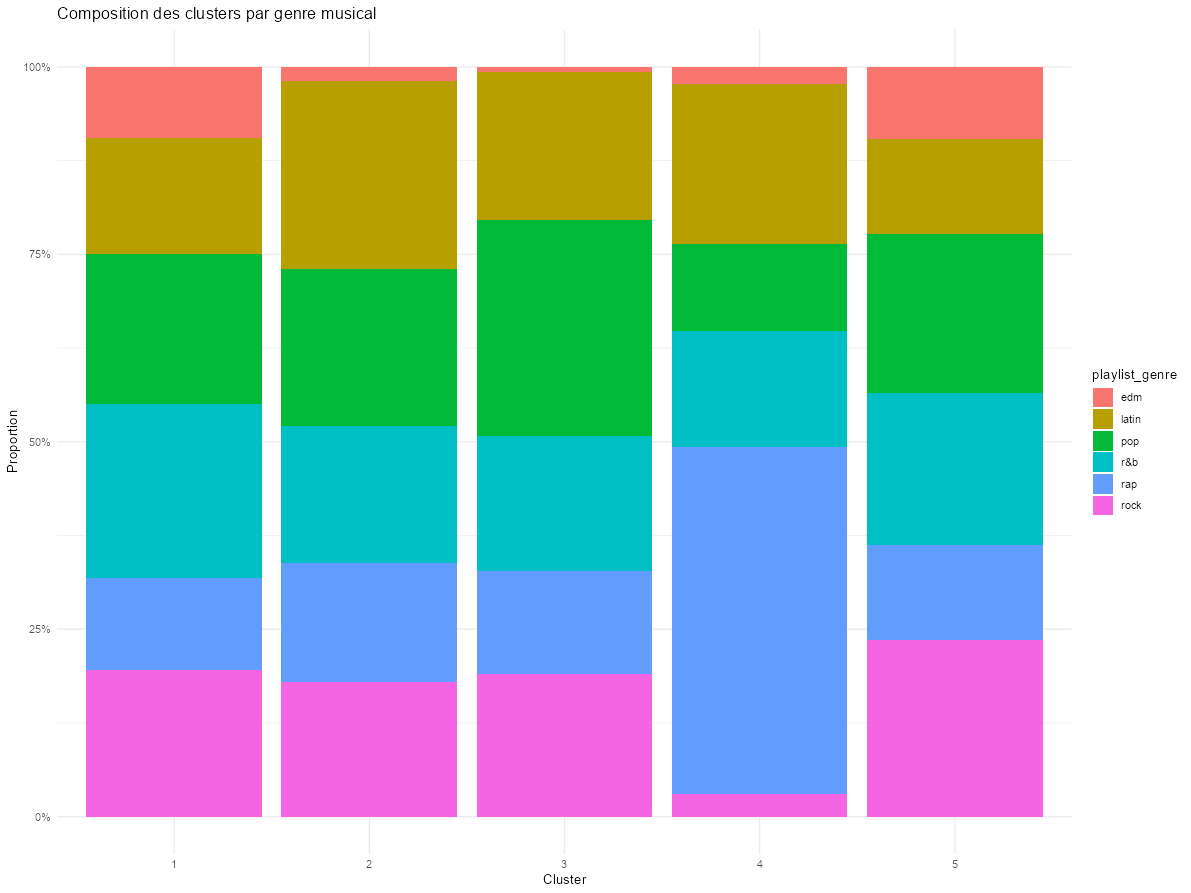

In [19]:
# Boxplots variables audio par cluster
vars_audio <- intersect(c("energy", "danceability", "valence", "sqrt_acousticness", "sqrt_speechiness", "tempo", "log_liveness", "loudness", "instrumentalness", "sqrt_duration_ms"), colnames(quanti_sample))

df_long <- cbind(spotify_sample, as.data.frame(quanti_sample)[, vars_audio]) %>%
  pivot_longer(cols = all_of(vars_audio),
               names_to = "variable",
               values_to = "valeur")

ggplot(df_long, aes(x = cluster_hac, y = valeur, fill = cluster_hac)) +
  geom_boxplot(outlier.size = 0.3, alpha = 0.7) +
  facet_wrap(~variable, scales = "free_y") +
  theme_minimal() +
  labs(title = "Profil audio des clusters (CAH)", x = "Cluster", y = "Valeur normalisée")

# Barplot genre par cluster
ggplot(spotify_sample, aes(x = cluster_hac, fill = playlist_genre)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Composition des clusters par genre musical", y = "Proportion", x = "Cluster")

Le dendrogramme ne présente pas de saut franc suggérant un nombre de clusters naturel, ce qui confirme l'absence de structure hiérarchique claire. Les genres musicaux étant par nature des catégories qui se chevauchent, nous appliquons enfin les Modèles de Mélange Gaussien (GMM), une approche probabiliste plus adaptée à des frontières floues entre groupes.

## 3. Modèles de Mélange Gaussien (GMM)

In [25]:
gmm <- Mclust(vocal_df, G = 6)

# Résumé
summary(gmm)

# Assignation des clusters
vocal_df$cluster_gmm <- as.factor(gmm$classification)

# Visualisation sur PCA
ggplot(df_plot %>% mutate(cluster_gmm = vocal_df$cluster_gmm),
       aes(x = Dim1, y = Dim2, color = cluster_gmm)) +
  geom_point(alpha = 0.3, size = 0.8) +
  theme_minimal() +
  labs(title = "GMM (k=6) sur coordonnées PCA")


fitting ...
  |=======================================================================================================================| 100%


: [1m[33mError[39m in `mutate()`:[22m
[1m[22m[36mℹ[39m In argument: `cluster_gmm = vocal_df$cluster_gmm`.
[1mCaused by error:[22m
[1m[22m[33m![39m `cluster_gmm` must be size 5000 or 1, not 28330.

In [26]:
summary(vocal_df)

  danceability        energy            valence           tempo        sqrt_speechiness sqrt_acousticness sqrt_duration_ms
 Min.   :0.0000   Min.   :0.000175   Min.   :0.0000   Min.   :  0.00   Min.   :0.0000   Min.   :0.0000    Min.   : 63.25  
 1st Qu.:0.5610   1st Qu.:0.579000   1st Qu.:0.3290   1st Qu.: 99.97   1st Qu.:0.2025   1st Qu.:0.1200    1st Qu.:433.29  
 Median :0.6700   Median :0.722000   Median :0.5120   Median :121.99   Median :0.2502   Median :0.2823    Median :465.74  
 Mean   :0.6534   Mean   :0.698348   Mean   :0.5105   Mean   :120.95   Mean   :0.3011   Mean   :0.3361    Mean   :471.89  
 3rd Qu.:0.7600   3rd Qu.:0.843000   3rd Qu.:0.6950   3rd Qu.:134.00   3rd Qu.:0.3647   3rd Qu.:0.5099    3rd Qu.:504.94  
 Max.   :0.9830   Max.   :1.000000   Max.   :0.9910   Max.   :239.44   Max.   :0.9581   Max.   :0.9970    Max.   :719.59  
  log_liveness     cqrt_loudness    cluster_gmm
 Min.   :0.00000   Min.   :-3.595   1:6117     
 1st Qu.:0.08856   1st Qu.:-2.026   2:2462 

In [31]:
# Boxplots variables audio par cluster
vars_audio <- intersect(c("energy", "danceability", "valence", "sqrt_acousticness", "sqrt_speechiness", "tempo", "log_liveness", "loudness", "instrumentalness", "sqrt_duration_ms"), colnames(quanti_sample))

df_long <- cbind(spotify_sample, as.data.frame(quanti_sample)[, vars_audio]) %>%
  pivot_longer(cols = all_of(vars_audio),
               names_to = "variable",
               values_to = "valeur")

a <- ggplot(df_long, aes(x = cluster_gmm, y = valeur, fill = cluster_gmm)) +
  geom_boxplot(outlier.size = 0.3, alpha = 0.7) +
  facet_wrap(~variable, scales = "free_y") +
  theme_minimal() +
  labs(title = "Profil audio des clusters (GMM)", x = "Cluster", y = "Valeur normalisée")

# Barplot genre par cluster
b <- ggplot(spotify_sample, aes(x = cluster_gmm, fill = playlist_genre)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  labs(title = "Composition des clusters par genre musical", y = "Proportion", x = "Cluster")

ggsave("a.png", plot = a, width = 10, height = 6, dpi = 300)
ggsave("b.png", plot = b, width = 10, height = 6, dpi = 300)

Les trois méthodes ont été appliquées sur les variables brutes normalisées et sur les coordonnées des 5 premières composantes de l'ACP. Nous comparons maintenant leurs résultats via l'Adjusted Rand Index (ARI), qui mesure la concordance entre deux partitions d'un jeu de données, une valeur proche de 0 indiquant une correspondance quasi aléatoire, tant qu'une valeur proche de 1 indique une forte correspondance.

In [29]:
# Comparaison GMM vs genre
ari_gmm_genre <- adjustedRandIndex(spotify_sample$cluster_gmm, spotify_sample$playlist_genre)
cat("ARI (GMM vs genre) :", round(ari_gmm_genre, 3))

# Comparaison GMM vs k-means
ari_gmm_km <- adjustedRandIndex(spotify_sample$cluster_gmm, spotify_sample$cluster_km)
cat(" ARI (GMM vs k-means) :", round(ari_gmm_km, 3))

# Comparaison GMM vs HAC
ari_gmm_hac <- adjustedRandIndex(spotify_sample$cluster_gmm, spotify_sample$cluster_hac)
cat(" ARI (GMM vs HAC) :", round(ari_gmm_hac, 3), "\n")

cat("ARI k-means vs genre :", round(adjustedRandIndex(spotify_sample$cluster_km, spotify_sample$playlist_genre), 3), "\n")
cat("ARI HAC vs genre     :", round(adjustedRandIndex(spotify_sample$cluster_hac, spotify_sample$playlist_genre), 3), "\n")
cat("ARI GMM vs genre     :", round(adjustedRandIndex(spotify_sample$cluster_gmm, spotify_sample$playlist_genre), 3), "\n")

ARI (GMM vs genre) : 0.051 ARI (GMM vs k-means) : 0.133 ARI (GMM vs HAC) : 0.169 
ARI k-means vs genre : 0.043 
ARI HAC vs genre     : 0.039 
ARI GMM vs genre     : 0.051 


L'ensemble des méthodes testées produit des ARI inférieurs à 0.1 vis-à-vis des genres, et les méthodes ne sont pas en accord entre elles. Cela confirme que les caractéristiques audio seules ne permettent pas de retrouver les genres musicaux par clustering non supervisé. Les morceaux du jeu de données forment un continuum audio sans frontières naturelles correspondant aux genres, mais comme le montre plus haut la NMF, des frontières se dégagent sur les caractères audio des morceaux.